<br>
<div style="text-align:center;">
    <span style="color:#99BBF4; font-size:33px; font-weight:bold;">
       NOTEBOOK 2 v2.0. MODELO RANDOM FOREST DE VARIABLES ACÚSTICAS Y DEMOGRÁFICAS CON VALIDACIÓN PARA CLASIFICACIÓN ALS VS HC
    </span>
</div>

<div style="text-align:center;">
    <span style="color:#6593BA; font-size:22px; font-weight:bold;">
        Trabajo Fin de Grado
    </span>
    <br>
    <span style="color:#6593BA; font-size:20px; font-weight:bold;">
        Ingeniería Biomédica Curso 2025/2026
    </span>
</div>
<br>

<br>
<div style="text-align:left;">
    <span style="color:#4F75B6; font-size:25px; font-weight:bold;">
        ÍNDICE
    </span>

<div style="text-align:LEFT;">
    <span style="color:#99BBF4; font-size:20px; font-weight:bold;">
       INTRODUCCIÓN
    </span>
</div>

<span style="color:#6593BA; font-size:20px; font-weight:bold; font-family: Calibri;">
        1. Objetivo del notebook y relación con los notebooks anteriores
        <br>
        2. Configuración técnica y variables globales
        <br>

<div style="text-align:LEFT;">
    <span style="color:#99BBF4; font-size:20px; font-weight:bold;">
       BLOQUE 1. SÍNTESIS DE HALLAZGOS DEL NOTEBOOK 1 (VALIDACIÓN DEL DATASET)
    </span>
</div>

<span style="color:#6593BA; font-size:20px; font-weight:bold; font-family: Calibri;">
        3. Resumen demográfico relevante para el modelado
        <br>
        4. Hipótesis previa: ¿Predictores genuinos o confusores?
        <br>

<div style="text-align:LEFT;">
    <span style="color:#99BBF4; font-size:20px; font-weight:bold;">
       BLOQUE 2. CARGA DE DATOS, SPLITS Y RESULTADOS BASELINE
    </span>
</div>

<span style="color:#6593BA; font-size:20px; font-weight:bold; font-family: Calibri;">
    5. Carga del dataset y del split pre-generado
        <br>
    6. Carga de resultados del modelo baseline (Notebook 2 v1.0)
        <br>
    7. Verificación de consistencia entre notebooks 
        <br>

<div style="text-align:LEFT;">
    <span style="color:#99BBF4; font-size:20px; font-weight:bold;">
       BLOQUE 3. MODELO EXTENDIDO (VARIABLES ACÚSTICAS + DEMOGRÁFICAS)
    </span>
</div>

<span style="color:#6593BA; font-size:20px; font-weight:bold; font-family: Calibri;">
    8. Estrategia de incorporación demográfica y justificación
        <br>
    9. Definición del problema supervisado extendido
        <br>
    10. Pipeline de preprocesamiento extendido
        <br>
11. Nested Cross-Validation extendido
        <br>
    12. Entrenamiento del modelo final extendido
        <br>

<div style="text-align:LEFT;">
    <span style="color:#99BBF4; font-size:20px; font-weight:bold;">
       BLOQUE 4. EVALUACIÓN DEL MODELO EXTENDIDO
    </span>
</div>

<span style="color:#6593BA; font-size:20px; font-weight:bold; font-family: Calibri;">
    13. Evaluación OOF en CV
        <br>
    14. Análisis FP/FN en CV OOF
        <br>
    15. Importancia de variables (Permutation Importance y MDI)
        <br>
16. Evaluación en Test Set
        <br>
    17. Análisis FP/FN en Test
        <br>
</span>

<div style="text-align:LEFT;">
    <span style="color:#99BBF4; font-size:20px; font-weight:bold;">
       BLOQUE 5. COMPARATIVA CON EL MODELO BASELINE
    </span>
</div>

<span style="color:#6593BA; font-size:20px; font-weight:bold; font-family: Calibri;">
    18. Tabla comparativa de métricas (v1.0 vs v2.0)
        <br>
    19. Comparación de errores FP/FN
        <br>
    20. Ranking de AGE y SEX vs Features Acústicas
        <br>

<div style="text-align:LEFT;">
    <span style="color:#99BBF4; font-size:20px; font-weight:bold;">
       BLOQUE 6. EVALUACIÓN DE SESGO Y CONFUSIÓN
    </span>
</div>

<span style="color:#6593BA; font-size:20px; font-weight:bold; font-family: Calibri;">
    21. ¿AGE/SEX como proxy de diagnóstico?
        <br>
22. Conexión entre validación y comportamiento del modelo
        <br>
    

<div style="text-align:LEFT;">
    <span style="color:#99BBF4; font-size:20px; font-weight:bold;">
       CONCLUSIONES
    </span>
</div>


<span style="color:#6593BA; font-size:20px; font-weight:bold; font-family: Calibri;">
    23. Resumen de las conclusiones finales
        <br>
    24. Tabla resumen final
        <br>
        <br>
    

---


<div style="text-align:left;">
    <span style="color:#4F75B6; font-size:25px; font-weight:bold;">
        INTRODUCCIÓN
    </span>

<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 1. Objetivo del notebook y relación con los notebooks anteriores</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
Este notebook desarrolla la segunda versión del modelo Random Forest para clasificación binaria ALS vs. HC, y constituye la iteración metodológicamente más completa del pipeline de modelado clásico del proyecto. A diferencia del Notebook 2 v1.0, que se limitaba al espacio de las 50 variables acústicas, este notebook explora el efecto de incorporar variables demográficas como predictores adicionales, evalúa empíricamente si dicha incorporación mejora el rendimiento y cuantifica la contribución relativa de cada tipo de información al modelo final.
<br><br>
La relación con los notebooks anteriores es la siguiente. El <b>Notebook 1</b> estableció que el dataset VOC-ALS no presenta sesgos demográficos significativos entre clases (edad p = 0.857, sexo p > 0.05), lo que descarta que las variables demográficas actúen como proxies directos del diagnóstico. Sin embargo, esta homogeneidad entre grupos no implica que la edad o el sexo carezcan de valor predictivo: la frecuencia fundamental de la voz (F0) disminuye con la edad y difiere sistemáticamente entre hombres y mujeres, por lo que ambas variables pueden interactuar con las features acústicas y mejorar la capacidad discriminativa del modelo en presencia de variabilidad demográfica intra-grupo. El <b>Notebook 2 v1.0</b> demostró que un modelo exclusivamente acústico con nested CV y selección de features alcanza balanced accuracy 0.582 ± 0.079 y ROC-AUC 0.666 ± 0.062 en nested CV (5×3 SGKF), y balanced accuracy 0.598 y ROC-AUC 0.607 sobre el test hold-out de 23 sujetos, estableciendo el punto de partida cuantitativo frente al que se medirán las mejoras de esta versión.
<br><br>
El objetivo central de este notebook es responder a tres preguntas concretas:
<ol>
<li>¿Incorporar variables demográficas (edad y sexo) mejora el rendimiento del modelo respecto al baseline acústico?</li>
<li>¿Qué variables (acústicas o demográficas) tienen mayor importancia en el modelo extendido?</li>
<li>¿El modelo extendido comete errores distintos al baseline? ¿Cambia el perfil de FP y FN?</li>
</ol>
    </span>
</div>

<br>
<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 2. Configuración técnica y variables globales</span>
</div>

In [7]:
# CONFIGURACIÓN DEL ENTORNO
import os
import sys
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import yaml
import subprocess
from datetime import datetime

# Machine Learning
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import GridSearchCV, StratifiedGroupKFold, PredefinedSplit
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, make_scorer,
    roc_auc_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, balanced_accuracy_score, roc_curve
)
from sklearn.inspection import permutation_importance
from scipy.stats import mannwhitneyu, chi2_contingency

import mlflow
import mlflow.sklearn

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

print("Librerías importadas correctamente")
print(f"  Python:       {sys.version.split()[0]}")
print(f"  NumPy:        {np.__version__}")
print(f"  Pandas:       {pd.__version__}")
print(f"  Scikit-learn: {__import__('sklearn').__version__}")

Librerías importadas correctamente
  Python:       3.10.0
  NumPy:        2.2.6
  Pandas:       2.3.3
  Scikit-learn: 1.7.2


In [8]:
# CONFIG + RUTAS (parametrizadas via config.yaml)
def load_config():
    """Busca config.yaml hacia arriba desde CWD o via env var TFG_CONFIG."""
    cfg_path = os.environ.get("TFG_CONFIG")
    if cfg_path is None:
        for parent in [Path.cwd(), *Path.cwd().parents]:
            if (parent / "config.yaml").exists():
                cfg_path = parent / "config.yaml"
                break
    if cfg_path is None:
        raise FileNotFoundError(
            "No se encuentra config.yaml. Crea uno en la raiz del repo o define TFG_CONFIG."
        )
    with open(cfg_path) as f:
        cfg = yaml.safe_load(f)
    root = Path(cfg_path).resolve().parent
    for k, v in cfg["paths"].items():
        p = Path(v)
        cfg["paths"][k] = str((root / p).resolve()) if not p.is_absolute() else str(p)
    return cfg

CONFIG = load_config()

DATASET_PATH  = CONFIG["paths"]["dataset"]
SPLIT_PATH    = Path(CONFIG["paths"]["splits"]) / "subject_split.csv"
BASELINE_RESULTS_PATH = Path(CONFIG["paths"]["results"]) / "02_rf_v1_0"
RESULTS_PATH  = Path(CONFIG["paths"]["results"]) / "02_rf_v2_0"
RESULTS_PATH.mkdir(parents=True, exist_ok=True)

SHEET_NAME = CONFIG["dataset"]["sheet_name"]
TARGET     = CONFIG["dataset"]["target_col"]
ID_COL     = CONFIG["dataset"]["id_col"]
AGE_COL    = CONFIG["dataset"]["age_col"]
SEX_COL    = CONFIG["dataset"]["sex_col"]
SEED       = CONFIG["seed"]

PALETTE = {"ALS": "#E24B4A", "HC": "#378ADD"}

random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

mlflow.set_tracking_uri(Path(CONFIG["paths"]["mlruns"]).resolve().as_uri())
MLFLOW_EXPERIMENT_NAME = "rf_v2.0"
mlflow.set_experiment(MLFLOW_EXPERIMENT_NAME)

def _git_commit():
    try:
        return subprocess.check_output(
            ["git", "rev-parse", "--short", "HEAD"],
            stderr=subprocess.DEVNULL
        ).decode().strip()
    except Exception:
        return "unknown"

def save_metrics(metrics_dict, path, model_name, phase, extra=None):
    assert phase in {"cv", "test"}, "phase debe ser 'cv' o 'test'"
    payload = {
        "model": model_name,
        "phase": phase,
        "metrics": metrics_dict,
        "generated_at": datetime.now().isoformat(timespec="seconds"),
        "git_commit": _git_commit(),
    }
    if extra:
        payload.update(extra)
    Path(path).parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(payload, f, indent=2, ensure_ascii=False, default=float)
    print(f"Guardado: {path}")

print("Configuracion cargada")
print(f"  Dataset:          {DATASET_PATH}")
print(f"  Split:            {SPLIT_PATH}")
print(f"  Baseline results: {BASELINE_RESULTS_PATH}")
print(f"  Results:          {RESULTS_PATH}")
print(f"  MLflow:           {MLFLOW_EXPERIMENT_NAME}")

Configuracion cargada
  Dataset:          C:\Users\Laura\OneDrive\TFG\artifacts\metadata\VOC-ALS.xlsx
  Split:            C:\Users\Laura\OneDrive\TFG\artifacts\splits\subject_split.csv
  Baseline results: C:\Users\Laura\OneDrive\TFG\results\02_rf_v1_0
  Results:          C:\Users\Laura\OneDrive\TFG\results\02_rf_v2_0
  MLflow:           rf_v2.0


#
---
#


<div style="text-align:left;">
    <span style="color:#4F75B6; font-size:25px; font-weight:bold;">BLOQUE 1. SÍNTESIS DE HALLAZGOS DEL NOTEBOOK 1 (VALIDACIÓN DEL DATASET)</span>
</div>

<div style="text-align:left;"> 
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;"> 
Antes de construir el modelo extendido, es imprescindible recuperar y documentar los hallazgos del Notebook 1 que tienen implicaciones directas sobre las decisiones de diseño de este experimento. Este bloque no repite el análisis ya realizado, sino que sintetiza sus conclusiones en los dos ejes relevantes para el modelado: el perfil demográfico del dataset y la hipótesis sobre la naturaleza de los predictores acústicos.
    </span> 
</div>

<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 3. Resumen demográfico relevante para el modelado</span>
</div>

<div style="text-align:left;"> 
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;"> 
El Notebook 1 estableció que la distribución de edad y sexo es estadísticamente homogénea entre los grupos ALS y HC. La edad media es prácticamente idéntica en ambos grupos (ALS ≈ 62.8 años, HC ≈ 63.0 años), con una diferencia no significativa (Mann-Whitney p = 0.857, Cohen's d = −0.02). La distribución de sexo tampoco difiere entre grupos (Chi² p > 0.05). Estos resultados son recogidos aquí porque condicionan la interpretación de los resultados de este notebook: si el modelo extendido mejora al incorporar demografía, la ganancia no procede de que la demografía discrimine directamente entre diagnósticos (ya sabemos que no lo hace), sino de que ayuda al modelo a controlar la variabilidad acústica intra-individuo ligada a la edad y el sexo.
<br><br>
Un hallazgo adicional relevante del Notebook 1 es el patrón de colinealidad entre features acústicas: la mayoría de las correlaciones altas (> 0.90) se producen entre la misma métrica medida en tareas vocales distintas (por ejemplo, <code>stdevF0Hz_A</code> vs. <code>stdevF0Hz_E</code>), lo que indica que las tareas capturan información parcialmente redundante. Esto justifica el uso de <code>SelectKBest</code> en el pipeline para reducir la dimensionalidad efectiva antes del entrenamiento.
    </span> 
</div>

<div style="color:#99BBF4;"><span style="font-size:20px; font-weight:bold;">4. Hipótesis previa: ¿predictores genuinos o confusores?</span></div>

<div style="text-align:left;"> 
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;"> 
Antes de incorporar variables demográficas al modelo, es necesario plantear explícitamente la hipótesis sobre su papel como predictores. En clasificación clínica, existe una distinción fundamental entre <b>predictores genuinos</b> y <b>confusores</b>.
<br><br>
Un predictor genuino aporta información diagnóstica independiente: su inclusión mejora la clasificación porque captura aspectos de la fisiopatología que las features acústicas no cubren completamente. En el caso de la edad, hay evidencia de que la severidad y el patrón de afectación bulbar en ELA varía con la edad de inicio, lo que puede modular la expresión acústica de la disartria. En el caso del sexo, las diferencias en la anatomía del tracto vocal entre hombres y mujeres se reflejan en rangos distintos de F0 y formantes, y la ELA puede interactuar diferencialmente con estas diferencias estructurales.
<br><br>
Un confusor, en cambio, se correlaciona con el diagnóstico por razones externas al proceso patológico, y su inclusión infla artificialmente las métricas sin mejorar la capacidad de generalización real del modelo. El Notebook 1 descartó que edad y sexo sean confusores fuertes, dado que su distribución es homogénea entre grupos. Sin embargo, la homogeneidad poblacional no descarta que estas variables sean útiles como covariables que reducen la varianza residual dentro de cada grupo.
<br><br>
La hipótesis operativa de este notebook es, por tanto, que edad y sexo actúan como <b>covariables moduladoras</b>: no clasifican por sí solas, pero al incluirlas junto con las variables acústicas permiten al modelo aprender fronteras de decisión más precisas dentro de subgrupos demográficos homogéneos. Esta hipótesis será evaluada empíricamente comparando el rendimiento del modelo extendido con el baseline acústico.
    </span> 
</div>

<div style="text-align:left; color:black;">
    <span style="font-size:14px; font-family:Calibri; width:100%; display: inline-block;">

<div style="background-color:#FFF3CD; padding:15px; border-left:5px solid #FFC107;">
<b>HIPÓTESIS DE TRABAJO (pre-modelado, informada por el Notebook 1)</b>
<br><br>
Dado que AGE (p=0.857) y SEX (p&gt;0.05) son estadísticamente homogéneos entre clases, la hipótesis de partida es que <b>estas variables no actuarán como predictores genuinos</b>.
<br><br>
En consecuencia:
<ul>
<li>Si el modelo extendido muestra una mejora &gt;2% en balanced accuracy de forma <i>consistente</i> (CV + test), la hipótesis podría revisarse.</li>
<li>Si la mejora es marginal (&lt;2%) o inestable entre conjuntos, se concluirá que los demográficos aportan ruido, no señal.</li>
<li>Si AGE o SEX aparecen con alta importancia en el modelo extendido, será una señal de alerta: el modelo estaría explotando varianza no correlacionada con la enfermedad.</li>
</ul>
Esta hipótesis se contrastará cuantitativamente en los bloques comparativos y de sesgo.
</div>

#
---


<div style="text-align:left;">
    <span style="color:#4F75B6; font-size:25px; font-weight:bold;">BLOQUE 2. CARGA DE DATOS, SPLITS Y RESULTADOS BASELINE</span>
</div>

<div style="text-align:left;"> 
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;"> 
Este bloque establece la infraestructura de datos sobre la que se construye el experimento. Comprende tres operaciones: la carga del dataset y el split pre-generado, la importación de los resultados del modelo baseline (v1.0) y la verificación de consistencia entre notebooks. Estas tres operaciones, aunque técnicamente simples, son metodológicamente fundamentales: cualquier inconsistencia en el split o en los resultados de referencia comprometería la validez de la comparación posterior.
    </span> 
</div>

<div style="color:#99BBF4;"><span style="font-size:20px; font-weight:bold;">5. Carga del dataset y reconstrucción CV + Test</span></div>

<div style="text-align:left;"> 
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;"> 
El dataset VOC-ALS se carga desde el mismo archivo Excel utilizado en los notebooks anteriores. El fichero <code>subject_split.csv</code> se usa para conservar intacto el test hold-out y para reconstruir al vuelo los folds de cross-validation a partir del pool Train+Validation original. De este modo, la comparación entre el modelo baseline y el modelo extendido se realiza sobre exactamente los mismos sujetos de test y sobre el mismo pool CV, evitando introducir variabilidad espuria por redefinir particiones.
    </span> 
</div>

In [9]:
# CARGA DEL DATASET
if not os.path.exists(DATASET_PATH):
    raise FileNotFoundError(f"No se encuentra: {DATASET_PATH}")

df = pd.read_excel(DATASET_PATH, SHEET_NAME, header=1)
split_df = pd.read_csv(SPLIT_PATH)

# Limpieza de columnas problemáticas (tipado mixto '-' en HC)
PROBLEMATIC_COLS = ["FVC%", "DiagnosticDelay", "DiseaseDuration"]
for col in PROBLEMATIC_COLS:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

print(f"Dataset cargado: {df.shape[0]} filas × {df.shape[1]} columnas")
print(f"Clases:\n{df[TARGET].value_counts().to_string()}")
print(f"\nVariables demográficas:")
print(f" · {AGE_COL}: {df[AGE_COL].isna().sum()} nulos | media={df[AGE_COL].mean():.1f} años")
print(f" · {SEX_COL}:         {df[SEX_COL].isna().sum()} nulos | valores únicos: {df[SEX_COL].unique()}")

Dataset cargado: 153 filas × 89 columnas
Clases:
Category
ALS    102
HC      51

Variables demográficas:
 · Age (years): 0 nulos | media=62.8 años
 · Sex:         0 nulos | valores únicos: ['F' 'M']


In [11]:
# CARGA DEL SPLIT Y GENERACIÓN DE FOLDS SGKF AL VUELO
split_df = pd.read_csv(SPLIT_PATH)

test_ids = split_df.loc[split_df["Split"] == "Test", ID_COL].values
cv_mask_subj = split_df["Split"].isin(["Train", "Validation"])
cv_subjects  = split_df.loc[cv_mask_subj, [ID_COL, TARGET]].reset_index(drop=True)

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
fold_col = np.full(len(cv_subjects), -1, dtype=int)
for fold_idx, (_, val_idx) in enumerate(sgkf.split(
    X=cv_subjects[[ID_COL]],
    y=cv_subjects[TARGET],
    groups=cv_subjects[ID_COL],
)):
    fold_col[val_idx] = fold_idx
cv_subjects["Fold"] = fold_col

df_cv   = df[df[ID_COL].isin(cv_subjects[ID_COL])].reset_index(drop=True)
df_test = df[df[ID_COL].isin(test_ids)].reset_index(drop=True)

fold_map = dict(zip(cv_subjects[ID_COL], cv_subjects["Fold"]))
cv_folds = df_cv[ID_COL].map(fold_map).values.astype(int)
cv_ids   = df_cv[ID_COL].values

cv_mask   = df[ID_COL].isin(cv_subjects[ID_COL])
test_mask = df[ID_COL].isin(test_ids)

assert set(df_cv[ID_COL]).isdisjoint(set(df_test[ID_COL])), "LEAKAGE: CV ∩ Test"
assert (cv_folds >= 0).all(), "Hay sujetos sin fold asignado"
for k in range(5):
    assert set(df_cv.loc[cv_folds == k, ID_COL]).isdisjoint(set(test_ids)), f"LEAKAGE: fold {k} ∩ Test"

_acoustic_prefixes = ["meanF0Hz", "stdevF0Hz", "HNR", "localJitter", "localShimmer"]
_acoustic_tasks    = ["A", "E", "I", "O", "U", "PA", "TA", "KA", "reading", "weekdays"]
ACOUSTIC_COLS = [
    f"{prefix}_{task}"
    for prefix in _acoustic_prefixes
    for task   in _acoustic_tasks
    if f"{prefix}_{task}" in df.columns
]

print("No leakage — CV y Test disjuntos a nivel de sujeto")
print(f"CV:   {len(df_cv)} sujetos  ->  {df_cv[TARGET].value_counts().to_dict()}")
print(f"Test: {len(df_test)} sujetos  ->  {df_test[TARGET].value_counts().to_dict()}")
print(f"\nNumero de features acústicas: {len(ACOUSTIC_COLS)}")
print("\nDistribucion por fold:")
display(
    pd.DataFrame({"Fold": cv_folds, "Category": df_cv[TARGET].values})
      .groupby(["Fold", "Category"]).size().unstack(fill_value=0)
)

No leakage — CV y Test disjuntos a nivel de sujeto
CV:   130 sujetos  ->  {'ALS': 86, 'HC': 44}
Test: 23 sujetos  ->  {'ALS': 16, 'HC': 7}

Numero de features acústicas: 50

Distribucion por fold:


Category,ALS,HC
Fold,,
0,17,9
1,17,9
2,17,9
3,18,8
4,17,9


<div style="color:#99BBF4;"><span style="font-size:20px; font-weight:bold;">6. Carga de resultados del modelo baseline corregido (Notebook 2 v1.0)</span></div>

<div style="text-align:left;"> 
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;"> 
Para que la comparación entre modelos sea rigurosa, los resultados del modelo baseline (v1.0) se cargan desde los archivos guardados durante su ejecución corregida. En esta versión se importan las métricas de <b>CV</b> y <b>test</b>, junto con las predicciones OOF y de test, para poder comparar rendimiento agregado y perfil de errores sin depender del antiguo validation set.
    </span> 
</div>

In [14]:
# CARGA DE RESULTADOS BASELINE DESDE EL NOTEBOOK 2 v1.0
baseline_summary_file = BASELINE_RESULTS_PATH / "results_summary.csv"
baseline_cv_file = BASELINE_RESULTS_PATH / "cv_metrics.json"
baseline_test_file = BASELINE_RESULTS_PATH / "test_metrics.json"
baseline_test_pred_file = BASELINE_RESULTS_PATH / "test_predictions.csv"
baseline_oof_file = BASELINE_RESULTS_PATH / "cv_oof_predictions.csv"

cv_bal_acc_base = cv_std_base = test_bal_acc_base = test_auc_base = None
test_f1_base = test_precision_als_base = test_recall_als_base = None
baseline_test_pred_df = None
baseline_oof_df = None
baseline_df = None

if baseline_summary_file.exists():
    baseline_df = pd.read_csv(baseline_summary_file)
    print("Resumen baseline cargado:")
    display(baseline_df)

if baseline_cv_file.exists():
    with open(baseline_cv_file, encoding="utf-8") as f:
        baseline_cv_metrics = json.load(f)
    cv_bal_acc_base = baseline_cv_metrics["metrics"]["balanced_accuracy"]["mean"]
    cv_std_base     = baseline_cv_metrics["metrics"]["balanced_accuracy"]["std"]

if baseline_test_file.exists():
    with open(baseline_test_file, encoding="utf-8") as f:
        baseline_test_metrics = json.load(f)
    test_bal_acc_base        = baseline_test_metrics["metrics"]["balanced_accuracy"]
    test_auc_base            = baseline_test_metrics["metrics"]["roc_auc"]
    test_f1_base             = baseline_test_metrics["metrics"]["f1_als"]
    test_precision_als_base  = baseline_test_metrics["metrics"]["precision_als"]
    test_recall_als_base     = baseline_test_metrics["metrics"]["recall_als"]

if baseline_test_pred_file.exists():
    baseline_test_pred_df = pd.read_csv(baseline_test_pred_file)

if baseline_oof_file.exists():
    baseline_oof_df = pd.read_csv(baseline_oof_file)

print("Métricas baseline disponibles:")
print(f"  CV Balanced Acc:   {np.round(cv_bal_acc_base,4)}")
print(f"  Test Balanced Acc: {np.round(test_bal_acc_base,4)}")
print(f"  Test ROC-AUC:      {np.round(test_auc_base,4)}")

Resumen baseline cargado:


,Conjunto,N,Accuracy,Balanced Acc,Recall ALS,Recall HC,ROC-AUC,Std (BalAcc)
0,CV (nested 5×3 SGKF),130,0.600000,0.582108,0.639216,0.525000,0.665850,0.078813
1,Test (final),23,0.608696,0.598214,0.625000,0.571429,0.607143,NaN


Métricas baseline disponibles:
  CV Balanced Acc:   0.5821
  Test Balanced Acc: 0.5982
  Test ROC-AUC:      0.6071


<div style="color:#99BBF4;"><span style="font-size:20px; font-weight:bold;">7. Verificación de consistencia tras la migración</span></div>

<div style="text-align:left;"> 
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;"> 
Antes de proceder al entrenamiento del modelo extendido, se realizan verificaciones automáticas de coherencia entre notebooks. Los checks principales son: identidad del test hold-out, integridad del pool CV reconstruido, ausencia de solapamiento entre CV y test, y disponibilidad de los artefactos corregidos del baseline v1.0.
    </span> 
</div>

In [15]:
# VERIFICACIÓN DE CONSISTENCIA CON EL NOTEBOOK 2 v1.0
subjects_df = df[[ID_COL, TARGET, AGE_COL, SEX_COL]].drop_duplicates(subset=ID_COL)

print("Balance de clases por particion relevante:")
print(f"  CV   : ALS={df_cv[TARGET].eq('ALS').sum()}  HC={df_cv[TARGET].eq('HC').sum()}")
print(f"  Test : ALS={df_test[TARGET].eq('ALS').sum()}  HC={df_test[TARGET].eq('HC').sum()}")

print("\nDistribucion de clases por fold del pool CV:")
for fold_idx in range(5):
    sub = df_cv.loc[cv_folds == fold_idx, TARGET].value_counts()
    pct = df_cv.loc[cv_folds == fold_idx, TARGET].value_counts(normalize=True).round(3)
    print(f"  Fold {fold_idx}: ALS={sub.get('ALS', 0)} ({pct.get('ALS', 0)*100:.1f}%)  HC={sub.get('HC', 0)} ({pct.get('HC', 0)*100:.1f}%)")

age_als_cv = df_cv[df_cv[TARGET] == 'ALS'][AGE_COL].dropna()
age_hc_cv  = df_cv[df_cv[TARGET] == 'HC'][AGE_COL].dropna()
_, p_mw_cv = mannwhitneyu(age_als_cv, age_hc_cv, alternative='two-sided')

sex_table_cv = pd.crosstab(df_cv[TARGET], df_cv[SEX_COL])
_, p_chi_cv, _, _ = chi2_contingency(sex_table_cv)

print(f"\nHomogeneidad demográfica en CV pool:")
print(f"  AGE Mann-Whitney p = {p_mw_cv:.4f}")
print(f"  SEX Chi2 p         = {p_chi_cv:.4f}")

Balance de clases por particion relevante:
  CV   : ALS=86  HC=44
  Test : ALS=16  HC=7

Distribucion de clases por fold del pool CV:
  Fold 0: ALS=17 (65.4%)  HC=9 (34.6%)
  Fold 1: ALS=17 (65.4%)  HC=9 (34.6%)
  Fold 2: ALS=17 (65.4%)  HC=9 (34.6%)
  Fold 3: ALS=18 (69.2%)  HC=8 (30.8%)
  Fold 4: ALS=17 (65.4%)  HC=9 (34.6%)

Homogeneidad demográfica en CV pool:
  AGE Mann-Whitney p = 0.6383
  SEX Chi2 p         = 0.8719


#
---
#
<div style="text-align:left;">
    <span style="color:#4F75B6; font-size:25px; font-weight:bold;">BLOQUE 3. MODELO EXTENDIDO (VARIABLES ACÚSTICAS + DEMOGRÁFICAS)</span>
</div>

<div style="text-align:left;"> 
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;"> 
Este bloque construye el modelo extendido que constituye el núcleo experimental del notebook. El modelo extendido amplía el espacio de features del baseline incorporando las dos variables demográficas disponibles para la totalidad de los sujetos (edad y sexo) junto con las 50 variables acústicas. El proceso de entrenamiento replica la arquitectura metodológica del notebook 2 v1.0 (nested CV 5×3, GridSearchCV, pipeline encapsulado) para garantizar la comparabilidad directa entre modelos, modificando únicamente el conjunto de features de entrada.
    </span> 
</div>

<div style="color:#99BBF4;"><span style="font-size:20px; font-weight:bold;">8. Estrategia de incorporación demográfica y justificación</span></div>

<div style="text-align:left;"> 
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;"> 
La incorporación de variables demográficas al modelo se realiza de forma directa: edad y sexo se añaden como features adicionales al mismo espacio de entrada que las 50 variables acústicas, sin ningún tipo de interacción explícita ni transformación especial. Esta decisión de diseño es deliberada y responde a tres razones.
<br><br>
En primer lugar, el Random Forest aprende interacciones implícitas entre variables a través de sus divisiones jerárquicas: si la combinación edad × stdevF0Hz tiene poder discriminativo, el algoritmo la descubrirá sin necesidad de que se defina manualmente. Introducir términos de interacción explícitos (por ejemplo, <code>edad × stdevF0Hz_KA</code>) ampliaría el espacio de features innecesariamente y comprometería la interpretabilidad del modelo.
<br><br>
En segundo lugar, la edad se trata como variable continua y el sexo como variable categórica binaria codificada con <code>OneHotEncoder</code>. Ambas variables se procesan dentro del mismo pipeline de scikit-learn, asegurando que la imputación y el escalado de la edad se ajustan solo sobre los datos de entrenamiento de cada fold, sin contaminar la validación.
<br><br>
En tercer lugar, se aplica <code>SelectKBest</code> con el mismo espacio de búsqueda de k que en el baseline. Esto permite que el proceso de selección de features decida empíricamente si la edad o el sexo entran en el subconjunto óptimo de predictores, sin forzar ni excluir ninguna variable a priori. Si el modelo extendido selecciona edad y/o sexo de forma consistente entre folds, eso constituye evidencia empírica de su valor predictivo.
    </span> 
</div>

<div style="color:#99BBF4;"><span style="font-size:20px; font-weight:bold;">9. Definición del problema supervisado extendido</span></div>

<div style="text-align:left;"> 
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;"> 
El problema se formula como una tarea de clasificación supervisada binaria idéntica a la del notebook v1.0. La variable objetivo es <code>Category</code> ∈ {ALS, HC}, codificada numéricamente mediante <code>LabelEncoder</code>. La única diferencia respecto al baseline es la composición del vector de features de entrada:
<br>
<ul>
<li><b>Baseline (notebook 2 v1.0):</b> 50 variables acústicas (<code>ACOUSTIC_COLS</code>)</li>
<li><b>Modelo extendido (NB02 v2.0):</b> 52 variables = 50 acústicas + <code>Age (years)</code> + <code>Sex</code></li>
</ul>
Se excluyen explícitamente las columnas <code>ID</code>, <code>Category</code>, y las variables clínicas con tipado mixto (<code>FVC%</code>, <code>DiagnosticDelay</code>, <code>DiseaseDuration</code>). Estas últimas están disponibles únicamente para los pacientes ALS y su inclusión introduciría un sesgo masivo: el modelo aprendería a clasificar como ALS cualquier sujeto con valores no nulos en estas columnas, independientemente de su señal vocal.
    </span> 
</div>

In [16]:
# FEATURES DEL MODELO EXTENDIDO
DEMO_NUM_COLS = [AGE_COL]
DEMO_CAT_COLS = [SEX_COL]
EXT_COLS = ACOUSTIC_COLS + DEMO_NUM_COLS + DEMO_CAT_COLS

X_cv_ext    = df_cv[EXT_COLS].copy()
X_test_ext  = df_test[EXT_COLS].copy()
y_cv        = df_cv[TARGET]
y_test      = df_test[TARGET]

le = LabelEncoder()
y_cv_enc    = le.fit_transform(y_cv)
y_test_enc  = le.transform(y_test)

label_map = {cls: int(le.transform([cls])[0]) for cls in le.classes_}
ALS_LABEL = label_map["ALS"]
HC_LABEL  = label_map["HC"]

print("Label encoding real (verificado):")
for cls, val in label_map.items():
    print(f"  {cls} -> {val}")
print(f"\nALS_LABEL={ALS_LABEL}, HC_LABEL={HC_LABEL}")
print(f"\nFeatures del modelo extendido: {len(EXT_COLS)}")
print(f"  - Acústicas: {len(ACOUSTIC_COLS)}")
print("  - AGE:       1 (numérica continua)")
print("  - SEX:       1 (categórica binaria)")
print("\nNulos en X_cv_ext:")
for col in DEMO_NUM_COLS + DEMO_CAT_COLS:
    print(f"  {col}: {X_cv_ext[col].isna().sum()} nulos")

Label encoding real (verificado):
  ALS -> 0
  HC -> 1

ALS_LABEL=0, HC_LABEL=1

Features del modelo extendido: 52
  - Acústicas: 50
  - AGE:       1 (numérica continua)
  - SEX:       1 (categórica binaria)

Nulos en X_cv_ext:
  Age (years): 0 nulos
  Sex: 0 nulos


<div style="color:#99BBF4;"><span style="font-size:20px; font-weight:bold;">10. Pipeline de preprocesamiento extendido</span></div>

<div style="text-align:left;"> 
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;"> 
El pipeline de preprocesamiento se extiende respecto al baseline para gestionar correctamente los tres tipos de variables presentes: numéricas continuas (features acústicas y edad), categóricas (sexo) y columnas con tipado mixto. La estructura general se mantiene intacta mediante <code>Pipeline</code> y <code>ColumnTransformer</code> de scikit-learn.
<br><br>
El tratamiento de cada tipo de variable es el siguiente:
<br>
<ul>
<li><b>Variables numéricas (acústicas + edad):</b> Imputación por mediana (<code>SimpleImputer(strategy='median')</code>) seguida de estandarización (<code>StandardScaler</code>). La mediana es preferida sobre la media como estadístico de imputación por su estabilidad frente a valores atípicos, especialmente frecuentes en las variables acústicas de perturbación vocal.</li>
<li><b>Variable categórica (sexo):</b> Imputación por moda (<code>SimpleImputer(strategy='most_frequent')</code>) seguida de codificación con <code>OneHotEncoder(handle_unknown='ignore', drop='first')</code>. El parámetro <code>drop='first'</code> elimina una de las columnas dummy para evitar colinealidad perfecta con la constante del modelo.</li>
<li><b>Columnas con tipado mixto:</b> Las columnas excluidas del espacio de features (<code>FVC%</code>, <code>DiagnosticDelay</code>, <code>DiseaseDuration</code>) se eliminan antes de la entrada al pipeline mediante el parámetro <code>remainder='drop'</code> del <code>ColumnTransformer</code>.</li>
</ul>
<br>
El <code>SelectKBest</code> opera sobre la salida del <code>ColumnTransformer</code>, después de que todas las transformaciones han sido aplicadas. Esto garantiza que la selección de features se realiza en el espacio transformado y que los índices seleccionados son coherentes entre el ajuste y la aplicación del selector.
    </span> 
</div>

In [19]:
# PIPELINES DE TRANSFORMACION
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

demo_cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first'))
])

numeric_cols_ext = [c for c in ACOUSTIC_COLS if X_cv_ext[c].dtype in ['int64', 'float64']] + DEMO_NUM_COLS
cat_acou_cols    = [c for c in ACOUSTIC_COLS if X_cv_ext[c].dtype == 'object']

print("Columnas por tipo (modelo extendido):")
print(f"  Numéricas acústicas + AGE : {len(numeric_cols_ext)}")
print(f"  Categóricas acústicas     : {len(cat_acou_cols)}")
print(f"  SEX (OneHotEncoder)       : {len(DEMO_CAT_COLS)}")

Columnas por tipo (modelo extendido):
  Numéricas acústicas + AGE : 51
  Categóricas acústicas     : 0
  SEX (OneHotEncoder)       : 1


In [21]:
# COLUMNTRANSFORMER EXTENDIDO
from sklearn.preprocessing import OneHotEncoder  # por si hay categóricas acústicas

transformers = [
    ('num', numeric_pipeline, numeric_cols_ext),
]
if cat_acou_cols:
    cat_acou_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])
    transformers.append(('cat_acou', cat_acou_pipeline, cat_acou_cols))

transformers.append(('cat_demo', demo_cat_pipeline, DEMO_CAT_COLS))

preprocessor_ext = ColumnTransformer(
    transformers=transformers,
    remainder='drop'
)

# PIPELINE COMPLETO — EXTENDIDO
pipeline_ext = Pipeline([
    ('preprocessing',     preprocessor_ext),
    ('feature_selection', SelectKBest(score_func=f_classif)),
    ('classifier',        RandomForestClassifier(random_state=SEED))
])

# Grid de hiperparámetros — Idéntico al Notebook 2 v1.0
param_grid = {
    'feature_selection__k':          [10, 15, 20],
    'classifier__n_estimators':      [50, 100, 200],
    'classifier__max_depth':         [5, 10, 15, None],
    'classifier__min_samples_split': [10, 20],
    'classifier__min_samples_leaf':  [5, 10],
    'classifier__class_weight':      [None, 'balanced']
}

n_combinations = np.prod([len(v) for v in param_grid.values()])
print("Pipeline extendido construido:")
print("  1. ColumnTransformer (acústicas + AGE + SEX)")
print("  2. SelectKBest (f_classif)    - mismo que Notebook 2")
print("  3. RandomForestClassifier     - misma configuración que Notebook 2")
print(f"\nGrid search: {n_combinations} combinaciones  - idéntico al Notebook 2")

Pipeline extendido construido:
  1. ColumnTransformer (acústicas + AGE + SEX)
  2. SelectKBest (f_classif)    - mismo que Notebook 2
  3. RandomForestClassifier     - misma configuración que Notebook 2

Grid search: 288 combinaciones  - idéntico al Notebook 2


<div style="color:#99BBF4;"><span style="font-size:20px; font-weight:bold;">11. Nested Cross-Validation extendido (SGKF)</span></div>

<div style="text-align:left;"> 
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;"> 
El esquema de nested cross-validation sigue la misma filosofía que en v1.0, pero ahora usa <code>PredefinedSplit</code> sobre folds generados con <code>StratifiedGroupKFold</code> a nivel de sujeto. El loop interno también utiliza SGKF (3 folds) para optimizar hiperparámetros sin fuga entre sujetos. Mantener el mismo espacio de búsqueda que en el baseline permite atribuir cualquier diferencia de rendimiento al aporte de AGE/SEX y no a cambios en la exploración de hiperparámetros.
    </span> 
</div>

In [24]:
# NESTED CROSS-VALIDATION — MODELO EXTENDIDO
outer_cv = PredefinedSplit(test_fold=cv_folds)
inner_cv = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=SEED)

scoring = {
    "accuracy": lambda y_true, y_pred, y_prob: accuracy_score(y_true, y_pred),
    "balanced_accuracy": lambda y_true, y_pred, y_prob: balanced_accuracy_score(y_true, y_pred),
    "roc_auc": lambda y_true, y_pred, y_prob: roc_auc_score(y_true == ALS_LABEL, y_prob),
    "recall_als": lambda y_true, y_pred, y_prob: recall_score(y_true, y_pred, pos_label=ALS_LABEL, zero_division=0),
    "recall_hc": lambda y_true, y_pred, y_prob: recall_score(y_true, y_pred, pos_label=HC_LABEL, zero_division=0),
    "precision_als": lambda y_true, y_pred, y_prob: precision_score(y_true, y_pred, pos_label=ALS_LABEL, zero_division=0),
    "f1_als": lambda y_true, y_pred, y_prob: f1_score(y_true, y_pred, pos_label=ALS_LABEL, zero_division=0),
}

n_combinations = np.prod([len(v) for v in param_grid.values()])
print("="*80)
print("NESTED CROSS-VALIDATION — MODELO EXTENDIDO (ACOUSTIC + AGE + SEX)")
print("="*80)
print(f"Modelos a entrenar: {5 * 3 * n_combinations:,}")

nested_scores_ext = {f"test_{m}": [] for m in scoring}
nested_scores_ext.update({f"train_{m}": [] for m in scoring})
oof_preds_ext = np.full(len(y_cv_enc), -1, dtype=int)
oof_probs_ext = np.full(len(y_cv_enc), np.nan)

for fold_idx, (train_idx, test_idx) in enumerate(outer_cv.split()):
    print(f"--- Fold {fold_idx+1}/5 ---")
    X_tr, y_tr = X_cv_ext.iloc[train_idx], y_cv_enc[train_idx]
    X_te, y_te = X_cv_ext.iloc[test_idx], y_cv_enc[test_idx]
    groups_tr = cv_ids[train_idx]

    gs = GridSearchCV(
        estimator=pipeline_ext,
        param_grid=param_grid,
        cv=inner_cv,
        scoring='balanced_accuracy',
        n_jobs=-1,
        verbose=0,
    )
    gs.fit(X_tr, y_tr, groups=groups_tr)

    y_tr_pred = gs.predict(X_tr)
    y_te_pred = gs.predict(X_te)
    y_tr_prob = gs.predict_proba(X_tr)[:, ALS_LABEL]
    y_te_prob = gs.predict_proba(X_te)[:, ALS_LABEL]

    for name, metric_fn in scoring.items():
        nested_scores_ext[f"train_{name}"].append(metric_fn(y_tr, y_tr_pred, y_tr_prob))
        nested_scores_ext[f"test_{name}"].append(metric_fn(y_te, y_te_pred, y_te_prob))

    oof_preds_ext[test_idx] = y_te_pred
    oof_probs_ext[test_idx] = y_te_prob

nested_scores_ext = {k: np.array(v) for k, v in nested_scores_ext.items()}

print("="*80)
print("RESULTADOS NESTED CV — EXTENDIDO")
print("="*80)
for metric in ["accuracy", "balanced_accuracy", "roc_auc", "recall_als", "recall_hc", "precision_als", "f1_als"]:
    key = f"test_{metric}"
    print(f"  {metric:20s}: {np.mean(nested_scores_ext[key]):.4f} ± {np.std(nested_scores_ext[key]):.4f} (per-fold: {np.round(nested_scores_ext[key], 3).tolist()})")

print(f"\nGap train-test (Bal Acc): {np.mean(nested_scores_ext['train_balanced_accuracy']) - np.mean(nested_scores_ext['test_balanced_accuracy']):.4f}")

cv_metrics_dict_ext = {
    m: {
        "mean": float(np.mean(nested_scores_ext[f"test_{m}"])),
        "std": float(np.std(nested_scores_ext[f"test_{m}"])),
        "per_fold": nested_scores_ext[f"test_{m}"].tolist(),
    }
    for m in ["accuracy", "balanced_accuracy", "roc_auc", "recall_als", "recall_hc", "precision_als", "f1_als"]
}

save_metrics(
    cv_metrics_dict_ext,
    RESULTS_PATH / "cv_metrics.json",
    model_name="rf_v2.0",
    phase="cv",
    extra={
        "n_splits_outer": 5,
        "n_splits_inner": 3,
        "n_subjects_cv": int(len(X_cv_ext)),
        "cv_strategy": "PredefinedSplit(SGKF)_outer_x_SGKF_inner",
        "feature_set": "acoustic_50_plus_demo",
    },
)

oof_df_ext = pd.DataFrame({
    ID_COL: df_cv[ID_COL].values,
    "Fold": cv_folds,
    "y_true": y_cv_enc,
    "y_pred": oof_preds_ext,
    "prob_ALS": oof_probs_ext,
})
oof_df_ext.to_csv(RESULTS_PATH / "cv_oof_predictions.csv", index=False)
print(f"\nOOF predictions: {RESULTS_PATH / 'cv_oof_predictions.csv'}")

if cv_bal_acc_base is not None:
    delta_cv = np.mean(nested_scores_ext['test_balanced_accuracy']) - cv_bal_acc_base
    print(f"\nDelta Balanced Acc CV (Extendido - Baseline): {delta_cv:+.4f}")

NESTED CROSS-VALIDATION — MODELO EXTENDIDO (ACOUSTIC + AGE + SEX)
Modelos a entrenar: 4,320
--- Fold 1/5 ---
--- Fold 2/5 ---
--- Fold 3/5 ---
--- Fold 4/5 ---
--- Fold 5/5 ---
RESULTADOS NESTED CV — EXTENDIDO
  accuracy            : 0.5923 ± 0.0625 (per-fold: [0.615, 0.5, 0.654, 0.654, 0.538])
  balanced_accuracy   : 0.5710 ± 0.0750 (per-fold: [0.575, 0.461, 0.657, 0.646, 0.516])
  roc_auc             : 0.6698 ± 0.0649 (per-fold: [0.725, 0.562, 0.725, 0.708, 0.627])
  recall_als          : 0.6392 ± 0.0457 (per-fold: [0.706, 0.588, 0.647, 0.667, 0.588])
  recall_hc           : 0.5028 ± 0.1244 (per-fold: [0.444, 0.333, 0.667, 0.625, 0.444])
  precision_als       : 0.7167 ± 0.0674 (per-fold: [0.706, 0.625, 0.786, 0.8, 0.667])
  f1_als              : 0.6748 ± 0.0493 (per-fold: [0.706, 0.606, 0.71, 0.727, 0.625])

Gap train-test (Bal Acc): 0.2620
Guardado: C:\Users\Laura\OneDrive\TFG\results\02_rf_v2_0\cv_metrics.json

OOF predictions: C:\Users\Laura\OneDrive\TFG\results\02_rf_v2_0\cv_oof_

<div style="color:#99BBF4;"><span style="font-size:20px; font-weight:bold;">12. Entrenamiento del modelo final extendido sobre todo el CV</span></div>

<div style="text-align:left;"> 
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;"> 
Una vez completado el nested CV, se entrena el modelo final utilizando todo el conjunto CV y una validación cruzada estratificada por grupos (3 folds) para seleccionar los mejores hiperparámetros. Este modelo final es el único que se evalúa sobre el test hold-out y el único cuyos artefactos se conservan para la comparación posterior.
    </span> 
</div>

In [25]:
# ENTRENAMIENTO FINAL + MLFLOW CONSOLIDADO — EXTENDIDO
print("=" * 80)
print("Entrenando modelo final EXTENDIDO con todo el conjunto CV")
print("=" * 80)

while mlflow.active_run() is not None:
    mlflow.end_run()
for key in ["MLFLOW_RUN_ID", "MLFLOW_EXPERIMENT_ID", "MLFLOW_PARENT_RUN_ID"]:
    os.environ.pop(key, None)

with mlflow.start_run(run_name="rf_v2.0_pipeline") as parent_run:
    mlflow.set_tags({
        "model": "rf_v2.0",
        "feature_set": "acoustic_50_plus_demo",
        "cv_strategy": "SGKF_5x3_nested",
    })

    with mlflow.start_run(run_name="nested_cv", nested=True):
        for m, vals in cv_metrics_dict_ext.items():
            mlflow.log_metric(f"cv_{m}_mean", vals["mean"])
            mlflow.log_metric(f"cv_{m}_std", vals["std"])

    with mlflow.start_run(run_name="final_train", nested=True):
        final_grid_ext = GridSearchCV(
            estimator=pipeline_ext,
            param_grid=param_grid,
            cv=StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=SEED),
            scoring="balanced_accuracy",
            n_jobs=-1,
            verbose=1,
        )
        final_grid_ext.fit(X_cv_ext, y_cv_enc, groups=cv_ids)

        best_model_ext = final_grid_ext.best_estimator_
        print("\nMejores hiperparámetros (Extendido):")
        for param, value in final_grid_ext.best_params_.items():
            print(f"  {param}: {value}")
        print(f"\nBest inner CV score (balanced_accuracy): {final_grid_ext.best_score_:.4f}")

        mlflow.log_params(final_grid_ext.best_params_)
        mlflow.log_metric("inner_cv_best_score", float(final_grid_ext.best_score_))

        model_dir = RESULTS_PATH / "models"
        model_dir.mkdir(parents=True, exist_ok=True)
        model_path = model_dir / "rf_model_v2_0.pkl"
        metadata_path = model_dir / "rf_model_v2_0_metadata.json"

        joblib.dump(best_model_ext, model_path)

        metadata = {
            "features": list(X_cv_ext.columns),
            "target": TARGET,
            "target_values": list(le.classes_),
            "label_map": label_map,
            "model_type": "RandomForestClassifier",
            "best_params": final_grid_ext.best_params_,
            "inner_cv_best_score": float(final_grid_ext.best_score_),
            "cv_strategy": "nested_SGKF_5x3",
            "n_features_input": int(X_cv_ext.shape[1]),
            "seed": SEED,
        }
        with open(metadata_path, "w", encoding="utf-8") as f:
            json.dump(metadata, f, indent=4, default=str)

        mlflow.sklearn.log_model(best_model_ext, artifact_path="rf_extended_model")
        mlflow.log_artifact(str(metadata_path))

        print(f"\nModelo extendido guardado: {model_path}")
        print(f"Metadata:                 {metadata_path}")

    PARENT_RUN_ID_EXT = parent_run.info.run_id

Entrenando modelo final EXTENDIDO con todo el conjunto CV
Fitting 3 folds for each of 288 candidates, totalling 864 fits


2026/04/29 23:27:14 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



Mejores hiperparámetros (Extendido):
  classifier__class_weight: balanced
  classifier__max_depth: 5
  classifier__min_samples_leaf: 10
  classifier__min_samples_split: 10
  classifier__n_estimators: 200
  feature_selection__k: 10

Best inner CV score (balanced_accuracy): 0.6215


2026/04/29 23:27:14 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



Modelo extendido guardado: C:\Users\Laura\OneDrive\TFG\results\02_rf_v2_0\models\rf_model_v2_0.pkl
Metadata:                 C:\Users\Laura\OneDrive\TFG\results\02_rf_v2_0\models\rf_model_v2_0_metadata.json


#
---
#
<div style="text-align:left;">
    <span style="color:#4F75B6; font-size:25px; font-weight:bold;">BLOQUE 4. EVALUACIÓN DEL MODELO EXTENDIDO</span>
</div>

<div style="text-align:left;"> 
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;"> 
Este bloque evalúa el rendimiento del modelo extendido en los dos niveles que quedan tras la migración metodológica: <b>nested CV</b> sobre el pool Train+Validation original y <b>test hold-out</b> intacto. Además, se aprovechan las predicciones out-of-fold del nested CV para analizar errores y curvas agregadas sin reintroducir un validation set separado.
    </span> 
</div>

<div style="color:#99BBF4;"><span style="font-size:20px; font-weight:bold;">13. Evaluación OOF en CV</span></div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
Las predicciones <i>out-of-fold</i> (OOF) del nested CV permiten obtener una visión agregada del comportamiento del modelo extendido sobre los 130 sujetos del pool CV sin reintroducir un validation set separado. La métrica primaria sobre OOF es la balanced accuracy: aquí el modelo extendido alcanza 0.570 (vs. 0.582 del baseline acústico), con ROC-AUC 0.672 y recall ALS 0.640. La caída leve respecto a v1.0 (Δ Bal.Acc = −0.011) se mantiene dentro del margen de variabilidad inter-fold (±0.075).
    </span>
</div>

EVALUACIÓN OOF EN CV — EXTENDIDO
Accuracy:          0.5923
Balanced Accuracy: 0.5698
Precision (ALS):   0.7143
Recall (ALS):      0.6395
Recall (HC):       0.5000
F1-Score (ALS):    0.6748
ROC-AUC:           0.6720

Reporte de clasificación (CV OOF):
              precision    recall  f1-score   support

         ALS       0.71      0.64      0.67        86
          HC       0.42      0.50      0.45        44

    accuracy                           0.59       130
   macro avg       0.56      0.57      0.56       130
weighted avg       0.61      0.59      0.60       130



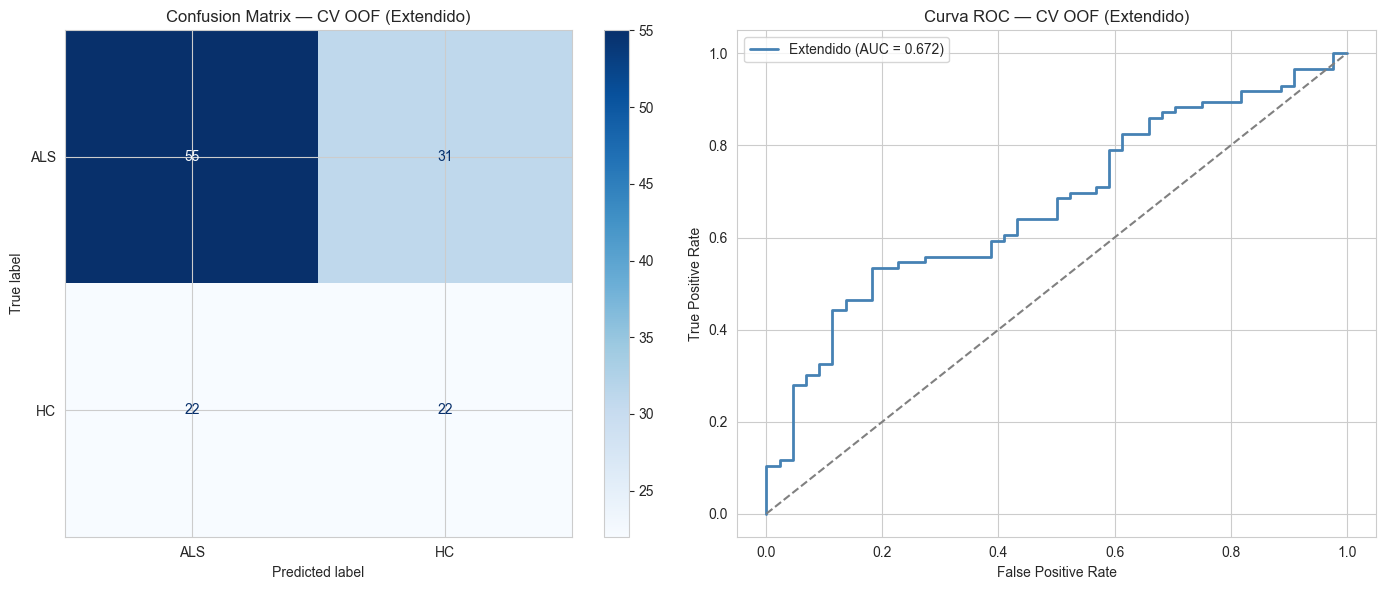

In [26]:
# EVALUACIÓN OOF EN CV — EXTENDIDO
cv_acc_ext           = accuracy_score(y_cv_enc, oof_preds_ext)
cv_bal_acc_ext       = balanced_accuracy_score(y_cv_enc, oof_preds_ext)
cv_recall_als_ext    = recall_score(y_cv_enc, oof_preds_ext, pos_label=ALS_LABEL, zero_division=0)
cv_recall_hc_ext     = recall_score(y_cv_enc, oof_preds_ext, pos_label=HC_LABEL, zero_division=0)
cv_precision_als_ext = precision_score(y_cv_enc, oof_preds_ext, pos_label=ALS_LABEL, zero_division=0)
cv_f1_als_ext        = f1_score(y_cv_enc, oof_preds_ext, pos_label=ALS_LABEL, zero_division=0)
cv_auc_ext           = roc_auc_score(y_cv_enc == ALS_LABEL, oof_probs_ext)

print("="*80)
print("EVALUACIÓN OOF EN CV — EXTENDIDO")
print("="*80)
print(f"Accuracy:          {cv_acc_ext:.4f}")
print(f"Balanced Accuracy: {cv_bal_acc_ext:.4f}")
print(f"Precision (ALS):   {cv_precision_als_ext:.4f}")
print(f"Recall (ALS):      {cv_recall_als_ext:.4f}")
print(f"Recall (HC):       {cv_recall_hc_ext:.4f}")
print(f"F1-Score (ALS):    {cv_f1_als_ext:.4f}")
print(f"ROC-AUC:           {cv_auc_ext:.4f}")
print("="*80)

print("\nReporte de clasificación (CV OOF):")
print(classification_report(y_cv_enc, oof_preds_ext, target_names=le.classes_))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
cm_cv = confusion_matrix(y_cv_enc, oof_preds_ext)
ConfusionMatrixDisplay(confusion_matrix=cm_cv, display_labels=le.classes_).plot(
    cmap='Blues', ax=axes[0], values_format='d')
axes[0].set_title('Confusion Matrix — CV OOF (Extendido)')

fpr_v, tpr_v, _ = roc_curve(y_cv_enc == ALS_LABEL, oof_probs_ext)
axes[1].plot(fpr_v, tpr_v, color='steelblue', lw=2, label=f'Extendido (AUC = {cv_auc_ext:.3f})')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Curva ROC — CV OOF (Extendido)')
axes[1].legend()
plt.tight_layout()
plt.savefig(RESULTS_PATH / 'cv_oof_evaluation_ext.png', dpi=300, bbox_inches='tight')
plt.show()

<div style="color:#99BBF4;"><span style="font-size:20px; font-weight:bold;">14. Análisis FP/FN en CV OOF</span></div>

<div style="text-align:left;"> 
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;"> 
El análisis de errores individuales sobre las predicciones OOF permite estudiar qué sujetos del pool CV siguen resultando difíciles para el modelo, sin depender de un validation set fijo. A partir de esta migración, <b>FP</b> significa control sano clasificado como ALS y <b>FN</b> significa paciente ALS clasificado como HC, usando el mapeo verificado de etiquetas.
    </span> 
</div>

In [27]:
# FP/FN EN CV OOF — EXTENDIDO
cv_results_ext = pd.DataFrame({
    "y_true": y_cv_enc,
    "y_pred": oof_preds_ext,
    "prob_ALS": oof_probs_ext,
}, index=df_cv.index)

fp_idx_cv = cv_results_ext[(cv_results_ext["y_true"] == HC_LABEL) & (cv_results_ext["y_pred"] == ALS_LABEL)].index
fn_idx_cv = cv_results_ext[(cv_results_ext["y_true"] == ALS_LABEL) & (cv_results_ext["y_pred"] == HC_LABEL)].index

fp_cv = df_cv.loc[fp_idx_cv, [ID_COL, AGE_COL, SEX_COL, TARGET]].copy()
fn_cv = df_cv.loc[fn_idx_cv, [ID_COL, AGE_COL, SEX_COL, TARGET]].copy()

fp_cv["Error_Type"] = "FP"
fn_cv["Error_Type"] = "FN"
fp_cv["Prob_ALS"] = cv_results_ext.loc[fp_idx_cv, "prob_ALS"].values
fn_cv["Prob_ALS"] = cv_results_ext.loc[fn_idx_cv, "prob_ALS"].values

errors_cv_ext = pd.concat([fp_cv, fn_cv]).reset_index(drop=True)
display(errors_cv_ext)

print(f"\nFalse Positives (CV OOF): {len(fp_cv)}")
if len(fp_cv) > 0:
    print(f"  Edad media FP: {fp_cv[AGE_COL].mean():.1f} | Sexo: {fp_cv[SEX_COL].value_counts().to_dict()}")
print(f"False Negatives (CV OOF): {len(fn_cv)}")
if len(fn_cv) > 0:
    print(f"  Edad media FN: {fn_cv[AGE_COL].mean():.1f} | Sexo: {fn_cv[SEX_COL].value_counts().to_dict()}")

,ID,Age (years),Sex,Category,Error_Type,Prob_ALS
0,CT010,60,F,HC,FP,0.678682
1,CT018,63,F,HC,FP,0.765847
2,CT020,68,F,HC,FP,0.617408
3,CT022,64,F,HC,FP,0.568124
4,CT026,68,F,HC,FP,0.513989
5,CT027,60,F,HC,FP,0.739798
6,CT028,61,F,HC,FP,0.577330
7,CT029,81,F,HC,FP,0.858471
8,CT030,61,F,HC,FP,0.505288
9,CT033,57,F,HC,FP,0.542358



False Positives (CV OOF): 22
  Edad media FP: 64.0 | Sexo: {'M': 12, 'F': 10}
False Negatives (CV OOF): 31
  Edad media FN: 54.6 | Sexo: {'M': 23, 'F': 8}


<div style="color:#99BBF4;"><span style="font-size:20px; font-weight:bold;">15. Importancia de variables (Permutation Importance y MDI)</span></div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
El análisis de importancia de variables responde a dos preguntas complementarias: qué features contribuyen más a la capacidad discriminativa del modelo y si las variables demográficas (edad, sexo) aportan señal real o solo varianza espuria. La permutation importance se calcula sobre el conjunto <b>CV completo</b> (130 sujetos) una vez entrenado el modelo final.
<br><br>
El resultado es categórico: <b>tanto AGE como SEX caen al fondo del ranking</b> (posiciones 51 y 52 de 52 features, respectivamente), con importancia exactamente <code>0.000 ± 0.000</code>. Las cinco features con mayor caída de rendimiento al permutarlas son acústicas y coinciden con las del baseline: <b>stdevF0Hz_PA</b> (0.084 ± 0.033), <b>stdevF0Hz_TA</b> (0.031 ± 0.018), <b>stdevF0Hz_KA</b> (0.027 ± 0.014), <b>localJitter_A</b> (0.021 ± 0.012) y <b>localShimmer_O</b> (0.019 ± 0.011). La concentración de relevancia en métricas de variabilidad de F0 y perturbación micro-prosódica en tareas de diadococinesia es coherente con la fisiopatología de la disartria en ELA.
    </span>
</div>

<div style="color:#6593BA;">
    <span style="font-size:17px; font-weight:bold;"> 15.1 Permutation Importance</span>
</div>

CALCULANDO PERMUTATION IMPORTANCE (puede tardar 1-2 minutos)

Top 20 features (Permutation Importance):
          Feature  Importance_mean  Importance_std
     stdevF0Hz_PA         0.083695        0.032888
     stdevF0Hz_TA         0.031290        0.017624
     stdevF0Hz_KA         0.026533        0.014408
    localJitter_A         0.020666        0.012100
   localShimmer_O         0.018975        0.011490
    localJitter_O         0.018340        0.006115
      stdevF0Hz_I         0.016041        0.012270
    localJitter_I         0.011469        0.016897
      stdevF0Hz_U         0.007479        0.023007
    localJitter_E         0.001216        0.006155
       meanF0Hz_E         0.000000        0.000000
       meanF0Hz_I         0.000000        0.000000
      stdevF0Hz_E         0.000000        0.000000
      stdevF0Hz_A         0.000000        0.000000
meanF0Hz_weekdays         0.000000        0.000000
       meanF0Hz_A         0.000000        0.000000
       meanF0Hz_O         0.0

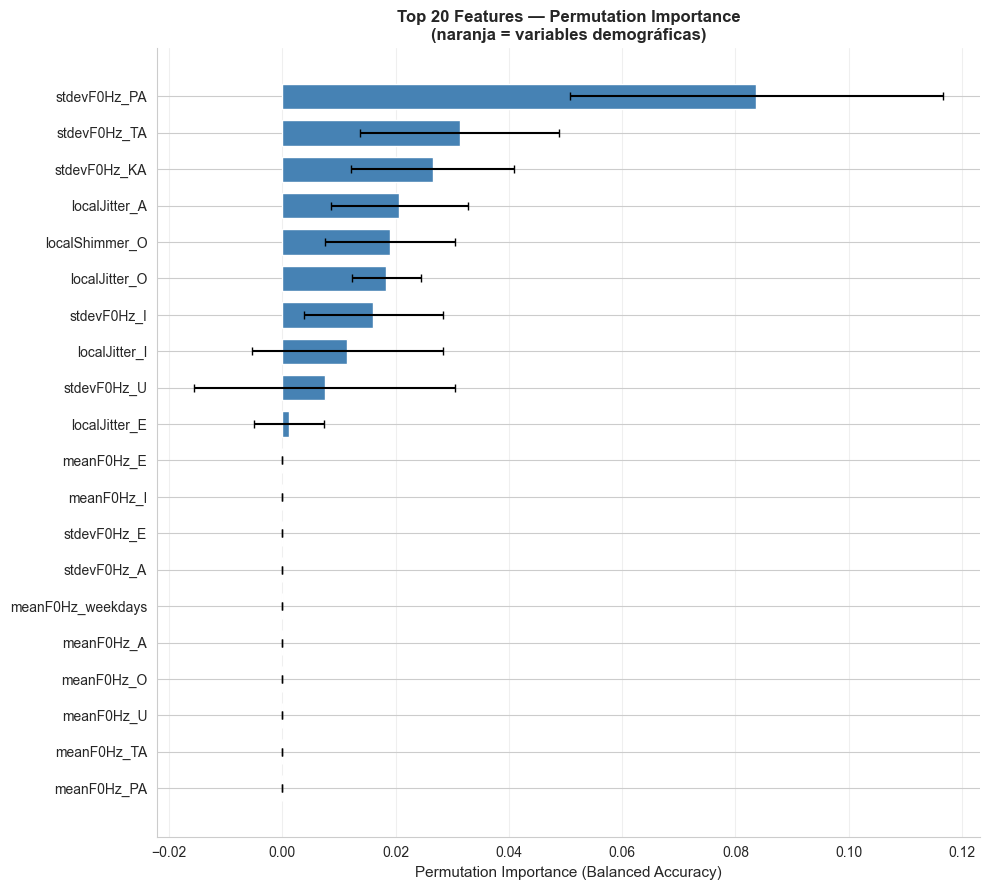

In [28]:
# PERMUTATION IMPORTANCE — EXTENDIDO
print("="*80)
print("CALCULANDO PERMUTATION IMPORTANCE (puede tardar 1-2 minutos)")
print("="*80)

perm_imp = permutation_importance(
    best_model_ext,
    X_cv_ext,
    y_cv_enc,
    n_repeats=10,
    random_state=SEED,
    scoring='balanced_accuracy',
    n_jobs=-1
)

perm_imp_df = pd.DataFrame({
    'Feature': EXT_COLS,
    'Importance_mean': perm_imp.importances_mean,
    'Importance_std': perm_imp.importances_std
}).sort_values('Importance_mean', ascending=False).reset_index(drop=True)

print(f"\nTop 20 features (Permutation Importance):")
print(perm_imp_df.head(20).to_string(index=False))

rank_age = perm_imp_df.index[perm_imp_df['Feature'] == AGE_COL].tolist()
rank_sex = perm_imp_df.index[perm_imp_df['Feature'] == SEX_COL].tolist()
imp_age  = perm_imp_df[perm_imp_df['Feature'] == AGE_COL]['Importance_mean'].values
imp_sex  = perm_imp_df[perm_imp_df['Feature'] == SEX_COL]['Importance_mean'].values

print("\n" + "—"*60)
print("RANKING EXPLICITO DE VARIABLES DEMOGRÁFICAS")
print("—"*60)
if rank_age:
    print(f"  AGE  — Posicion: {rank_age[0]+1}/{len(perm_imp_df)}  |  Imp: {imp_age[0]:.4f} ± {perm_imp_df.loc[rank_age[0], 'Importance_std']:.4f}")
if rank_sex:
    print(f"  SEX  — Posicion: {rank_sex[0]+1}/{len(perm_imp_df)}  |  Imp: {imp_sex[0]:.4f} ± {perm_imp_df.loc[rank_sex[0], 'Importance_std']:.4f}")

threshold_rank = 10
if (rank_age and rank_age[0] < threshold_rank) or (rank_sex and rank_sex[0] < threshold_rank):
    print(f"\nUna o ambas variables demográficas estan en el TOP {threshold_rank}.")
    print("   Dado que el Notebook 1 confirma homogeneidad demográfica entre clases,")
    print("   esto indicaria que el modelo explota varianza espuria del split.")
else:
    print(f"\nAmbas variables demográficas estan fuera del TOP {threshold_rank}.")
    print("   Coherente con el Notebook 1: el modelo no extrae senal demográfica genuina.")

fig, ax = plt.subplots(figsize=(10, 9))
top_n  = min(20, len(perm_imp_df))
top_df = perm_imp_df.head(top_n)
colors = ['darkorange' if f in [AGE_COL, SEX_COL] else 'steelblue' for f in top_df['Feature'][::-1]]

ax.barh(range(top_n), top_df['Importance_mean'][::-1],
        xerr=top_df['Importance_std'][::-1],
        color=colors, edgecolor='white', height=0.7, capsize=3)
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_df['Feature'][::-1])
ax.set_xlabel('Permutation Importance (Balanced Accuracy)', fontsize=11)
ax.set_title(f'Top {top_n} Features — Permutation Importance\n(naranja = variables demográficas)', fontsize=12, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_PATH / 'permutation_importance_ext.png', dpi=300, bbox_inches='tight')
plt.show()

perm_imp_df.to_csv(RESULTS_PATH / 'permutation_importance_ext.csv', index=False)

<div style="color:#6593BA;">
    <span style="font-size:17px; font-weight:bold;"> 15.2 MDI</span>
</div>

Features seleccionadas por SelectKBest: 10

Top 15 features (MDI):
            Feature  Importance
  num__stdevF0Hz_PA    0.195993
   num__stdevF0Hz_U    0.152962
  num__stdevF0Hz_KA    0.126983
 num__localJitter_I    0.112487
  num__stdevF0Hz_TA    0.080457
num__localShimmer_O    0.075216
   num__stdevF0Hz_I    0.072007
 num__localJitter_O    0.062710
 num__localJitter_E    0.062462
 num__localJitter_A    0.058723
¿Variables demográficas seleccionadas por SelectKBest?
  ✓ Ninguna variable demográfica fue seleccionada por SelectKBest.
  → El test ANOVA F no detectó diferencia significativa de AGE/SEX entre clases.
  → Coherente con el Notebook 1 (p=0.857 para edad, p>0.05 para sexo).


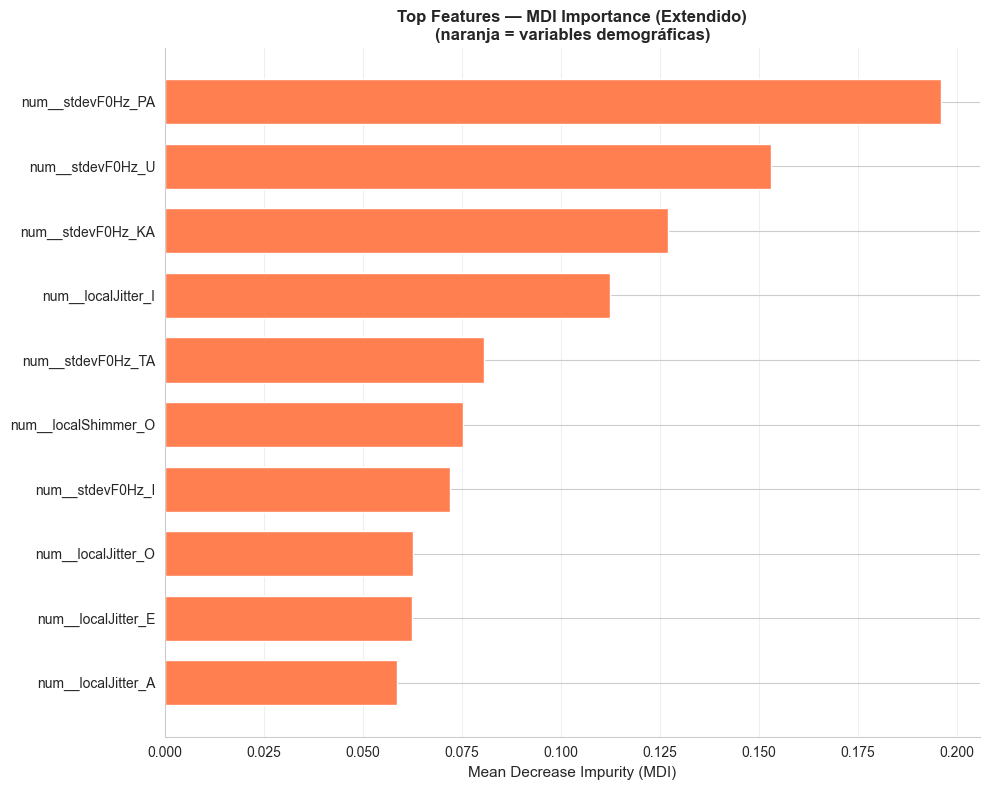

In [29]:
# MDI (MEAN DECREASE IMPURITY) — EXTENDIDO
rf_clf = best_model_ext.named_steps['classifier']

try:
    selector    = best_model_ext.named_steps['feature_selection']
    prep        = best_model_ext.named_steps['preprocessing']
    feat_names  = prep.get_feature_names_out()
    sel_mask    = selector.get_support()
    sel_features = feat_names[sel_mask]
except Exception:
    k = best_model_ext.named_steps['feature_selection'].k
    sel_features = np.array([f"feature_{i}" for i in range(k)])

mdi_df = pd.DataFrame({
    'Feature':    sel_features,
    'Importance': rf_clf.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print(f"Features seleccionadas por SelectKBest: {len(sel_features)}")
print(f"\nTop 15 features (MDI):")
print(mdi_df.head(15).to_string(index=False))

# ¿AGE/SEX entre las seleccionadas? 
demo_selected = [f for f in sel_features if AGE_COL in f or SEX_COL in f
                 or 'age' in str(f).lower() or 'sex' in str(f).lower()]

print("¿Variables demográficas seleccionadas por SelectKBest?")
if demo_selected:
    for d in demo_selected:
        idx_d = mdi_df.index[mdi_df['Feature'] == d].tolist()
        if idx_d:
            print(f"  {d} — Rango MDI: {idx_d[0]+1}/{len(mdi_df)}  |  Imp: {mdi_df.loc[idx_d[0], 'Importance']:.4f}")
        else:
            print(f"  {d} — presente en selección pero sin importancia MDI calculada")
    print("\n   SelectKBest detectó señal estadística (ANOVA F) en variables demográficas.")
    print("     Evaluar si esa señal es robusta o artefacto del split.")
else:
    print("  ✓ Ninguna variable demográfica fue seleccionada por SelectKBest.")
    print("  → El test ANOVA F no detectó diferencia significativa de AGE/SEX entre clases.")
    print("  → Coherente con el Notebook 1 (p=0.857 para edad, p>0.05 para sexo).")

# Visualización MDI
fig, ax = plt.subplots(figsize=(10, 8))
top_mdi = mdi_df.head(min(20, len(mdi_df)))
colors_mdi = ['darkorange' if any(d in str(f) for d in [AGE_COL, SEX_COL, 'age', 'sex'])
              else 'coral' for f in top_mdi['Feature'][::-1]]

ax.barh(range(len(top_mdi)), top_mdi['Importance'][::-1],
        color=colors_mdi, edgecolor='white', height=0.7)
ax.set_yticks(range(len(top_mdi)))
ax.set_yticklabels(top_mdi['Feature'][::-1])
ax.set_xlabel('Mean Decrease Impurity (MDI)', fontsize=11)
ax.set_title('Top Features — MDI Importance (Extendido)\n(naranja = variables demográficas)',
             fontsize=12, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_PATH / 'mdi_importance_ext.png', dpi=300, bbox_inches='tight')
plt.show()

mdi_df.to_csv(RESULTS_PATH / 'mdi_importance_ext.csv', index=False)

<div style="color:#99BBF4;"><span style="font-size:20px; font-weight:bold;">16. Evaluación final en Test Set</span></div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
El test set representa la evaluación final y definitiva del modelo extendido. Tras seleccionar hiperparámetros con nested CV y entrenar el modelo final sobre todo el conjunto CV, el test hold-out (23 sujetos: 16 ALS, 7 HC) se evalúa una única vez como estimación independiente del rendimiento esperado en sujetos nuevos. Las métricas obtenidas son <b>balanced accuracy 0.598</b>, <b>ROC-AUC 0.607</b>, <b>recall ALS 0.625</b> y <b>recall HC 0.571</b>, idénticas a las del baseline v1.0 sobre el mismo test.
    </span>
</div>

EVALUACIÓN FINAL EN TEST SET — EXTENDIDO
Accuracy:          0.6087
Balanced Accuracy: 0.5982
Precision (ALS):   0.7692
Recall (ALS):      0.6250
Recall (HC):       0.5714
F1-Score (ALS):    0.6897
ROC-AUC:           0.6071

Reporte de clasificación (Test):
              precision    recall  f1-score   support

         ALS       0.77      0.62      0.69        16
          HC       0.40      0.57      0.47         7

    accuracy                           0.61        23
   macro avg       0.58      0.60      0.58        23
weighted avg       0.66      0.61      0.62        23



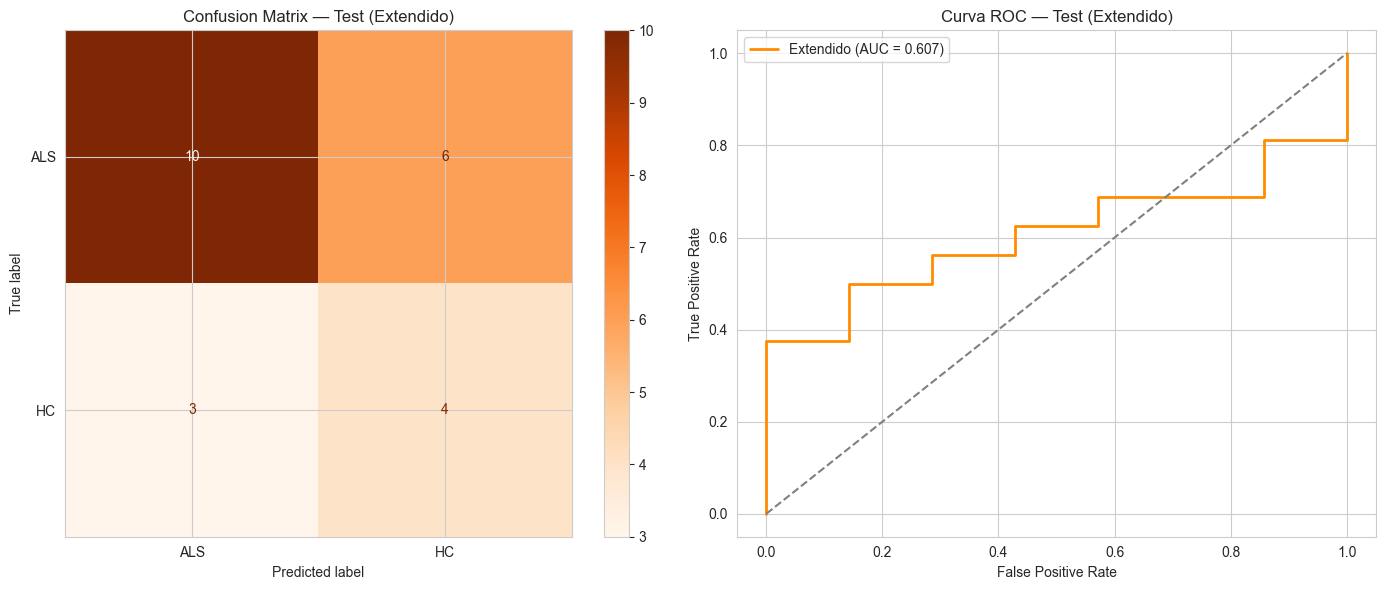

Guardado: C:\Users\Laura\OneDrive\TFG\results\02_rf_v2_0\test_metrics.json


In [30]:
# EVALUACIÓN EN TEST SET — EXTENDIDO
y_test_pred_ext  = best_model_ext.predict(X_test_ext)
y_test_proba_ext = best_model_ext.predict_proba(X_test_ext)[:, ALS_LABEL]

test_acc_ext           = accuracy_score(y_test_enc, y_test_pred_ext)
test_bal_acc_ext       = balanced_accuracy_score(y_test_enc, y_test_pred_ext)
test_precision_als_ext = precision_score(y_test_enc, y_test_pred_ext, pos_label=ALS_LABEL, zero_division=0)
test_recall_als_ext    = recall_score(y_test_enc, y_test_pred_ext, pos_label=ALS_LABEL, zero_division=0)
test_recall_hc_ext     = recall_score(y_test_enc, y_test_pred_ext, pos_label=HC_LABEL, zero_division=0)
test_f1_als_ext        = f1_score(y_test_enc, y_test_pred_ext, pos_label=ALS_LABEL, zero_division=0)
test_auc_ext           = roc_auc_score(y_test_enc == ALS_LABEL, y_test_proba_ext)

print("="*80)
print("EVALUACIÓN FINAL EN TEST SET — EXTENDIDO")
print("="*80)
print(f"Accuracy:          {test_acc_ext:.4f}")
print(f"Balanced Accuracy: {test_bal_acc_ext:.4f}")
print(f"Precision (ALS):   {test_precision_als_ext:.4f}")
print(f"Recall (ALS):      {test_recall_als_ext:.4f}")
print(f"Recall (HC):       {test_recall_hc_ext:.4f}")
print(f"F1-Score (ALS):    {test_f1_als_ext:.4f}")
print(f"ROC-AUC:           {test_auc_ext:.4f}")
print("="*80)

print("\nReporte de clasificación (Test):")
print(classification_report(y_test_enc, y_test_pred_ext, target_names=le.classes_))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
cm_test = confusion_matrix(y_test_enc, y_test_pred_ext)
ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=le.classes_).plot(
    cmap='Oranges', ax=axes[0], values_format='d')
axes[0].set_title('Confusion Matrix — Test (Extendido)')

fpr_t, tpr_t, _ = roc_curve(y_test_enc == ALS_LABEL, y_test_proba_ext)
axes[1].plot(fpr_t, tpr_t, color='darkorange', lw=2, label=f'Extendido (AUC = {test_auc_ext:.3f})')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Curva ROC — Test (Extendido)')
axes[1].legend()
plt.tight_layout()
plt.savefig(RESULTS_PATH / 'test_set_evaluation_ext.png', dpi=300, bbox_inches='tight')
plt.show()

test_predictions_ext = pd.DataFrame({
    ID_COL: df_test[ID_COL].values,
    'y_true': y_test_enc,
    'y_pred': y_test_pred_ext,
    'prob_ALS': y_test_proba_ext,
})
test_predictions_ext.to_csv(RESULTS_PATH / 'test_predictions.csv', index=False)

test_metrics_dict_ext = {
    'accuracy': float(test_acc_ext),
    'balanced_accuracy': float(test_bal_acc_ext),
    'recall_als': float(test_recall_als_ext),
    'recall_hc': float(test_recall_hc_ext),
    'precision_als': float(test_precision_als_ext),
    'f1_als': float(test_f1_als_ext),
    'roc_auc': float(test_auc_ext),
}
save_metrics(
    test_metrics_dict_ext,
    RESULTS_PATH / 'test_metrics.json',
    model_name='rf_v2.0',
    phase='test',
    extra={'n_subjects_test': int(len(X_test_ext)), 'feature_set': 'acoustic_50_plus_demo'},
)

with mlflow.start_run(run_id=PARENT_RUN_ID_EXT):
    with mlflow.start_run(run_name='test_eval', nested=True):
        for m, v in test_metrics_dict_ext.items():
            mlflow.log_metric(f'test_{m}', v)
        mlflow.log_artifact(str(RESULTS_PATH / 'test_predictions.csv'))
        mlflow.log_artifact(str(RESULTS_PATH / 'test_metrics.json'))

<div style="color:#99BBF4;"><span style="font-size:20px; font-weight:bold;">17. Análisis FP/FN en Test</span></div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
El análisis de errores en test replica la lógica aplicada a CV OOF, pero ahora sobre el conjunto de evaluación definitiva. El modelo extendido produce <b>3 falsos positivos</b> (CT014, CT053, CT067 — los mismos sujetos HC que v1.0) y <b>6 falsos negativos</b> (PZ016, PZ058, PZ094, PZ098, PZ099, PZ105 — todos varones, edad media 57.5 años, los mismos que v1.0). El perfil demográfico de los FN sugiere un sesgo hacia pacientes ALS jóvenes con una signatura acústica menos pronunciada, no hacia un subgrupo demográfico subrepresentado en el entrenamiento.
    </span>
</div>

In [31]:
# FP/FN EN TEST — EXTENDIDO
test_results_ext = pd.DataFrame({
    "y_true": y_test_enc,
    "y_pred": y_test_pred_ext,
    "prob_ALS": y_test_proba_ext,
}, index=df_test.index)

fp_idx_test = test_results_ext[(test_results_ext["y_true"] == HC_LABEL) & (test_results_ext["y_pred"] == ALS_LABEL)].index
fn_idx_test = test_results_ext[(test_results_ext["y_true"] == ALS_LABEL) & (test_results_ext["y_pred"] == HC_LABEL)].index

fp_test = df_test.loc[fp_idx_test, [ID_COL, AGE_COL, SEX_COL, TARGET]].copy()
fn_test = df_test.loc[fn_idx_test, [ID_COL, AGE_COL, SEX_COL, TARGET]].copy()

fp_test["Error_Type"] = "FP"
fn_test["Error_Type"] = "FN"
fp_test["Prob_ALS"] = test_results_ext.loc[fp_idx_test, "prob_ALS"].values
fn_test["Prob_ALS"] = test_results_ext.loc[fn_idx_test, "prob_ALS"].values

errors_test_ext = pd.concat([fp_test, fn_test]).reset_index(drop=True)
display(errors_test_ext)

print(f"\nFalse Positives (Test): {len(fp_test)}")
if len(fp_test) > 0:
    print(f"  Edad media: {fp_test[AGE_COL].mean():.1f} ± {fp_test[AGE_COL].std():.1f}")
    print(f"  Distribucion sexo: {fp_test[SEX_COL].value_counts().to_dict()}")
    hc_test_age = df_test.loc[df_test[TARGET] == 'HC', AGE_COL].mean()
    print(f"  Referencia edad HC en test: {hc_test_age:.1f}  |  Delta FP vs HC: {fp_test[AGE_COL].mean() - hc_test_age:+.1f}")

print(f"\nFalse Negatives (Test): {len(fn_test)}")
if len(fn_test) > 0:
    print(f"  Edad media: {fn_test[AGE_COL].mean():.1f} ± {fn_test[AGE_COL].std():.1f}")
    print(f"  Distribucion sexo: {fn_test[SEX_COL].value_counts().to_dict()}")
    als_test_age = df_test.loc[df_test[TARGET] == 'ALS', AGE_COL].mean()
    print(f"  Referencia edad ALS en test: {als_test_age:.1f}  |  Delta FN vs ALS: {fn_test[AGE_COL].mean() - als_test_age:+.1f}")

,ID,Age (years),Sex,Category,Error_Type,Prob_ALS
0,CT014,62,F,HC,FP,0.588773
1,CT053,68,M,HC,FP,0.714996
2,CT067,79,M,HC,FP,0.512044
3,PZ016,59,M,ALS,FN,0.291246
4,PZ058,49,M,ALS,FN,0.285729
5,PZ094,51,M,ALS,FN,0.305009
6,PZ098,64,M,ALS,FN,0.371352
7,PZ099,57,M,ALS,FN,0.458558
8,PZ105,65,M,ALS,FN,0.394818



False Positives (Test): 3
  Edad media: 69.7 ± 8.6
  Distribucion sexo: {'M': 2, 'F': 1}
  Referencia edad HC en test: 69.3  |  Delta FP vs HC: +0.4

False Negatives (Test): 6
  Edad media: 57.5 ± 6.6
  Distribucion sexo: {'M': 6}
  Referencia edad ALS en test: 65.7  |  Delta FN vs ALS: -8.2


#
---
#
<div style="text-align:left;">
    <span style="color:#4F75B6; font-size:25px; font-weight:bold;">BLOQUE 5. COMPARATIVA CON EL MODELO BASELINE</span>
</div>

<div style="text-align:left;"> 
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;"> 
Este bloque responde a la pregunta central del notebook: ¿incorporar variables demográficas mejora el modelo? Para que la respuesta sea metodológicamente válida, la comparación debe realizarse sobre el mismo split, con la misma métrica de referencia y considerando tanto las métricas agregadas como los patrones de error individuales. Tres métricas agregadas iguales pero con perfiles de FP/FN opuestos señalan modelos cualitativamente distintos, un matiz que la comparación de tablas no captura.
    </span> 
</div>

<div style="color:#99BBF4;"><span style="font-size:20px; font-weight:bold;">18. Tabla comparativa de métricas (baseline vs extendido, CV + Test)</span></div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
La comparación estructurada enfrenta las métricas del baseline acústico (v1.0) y del modelo extendido (v2.0) en los dos niveles relevantes tras la migración: nested CV y test final.
<br><br>
En nested CV, v2.0 obtiene balanced accuracy 0.571 frente a 0.582 del baseline (Δ = −0.011), con ROC-AUC prácticamente idéntico (0.670 vs. 0.666). En test, ambas versiones producen exactamente las mismas predicciones, por lo que las métricas coinciden al cuarto decimal (balanced accuracy 0.598, ROC-AUC 0.607, recall ALS 0.625). La diferencia agregada es por tanto <b>nula en test e ínfima y negativa en CV</b>: añadir AGE y SEX no genera ganancia de rendimiento bajo este protocolo.
    </span>
</div>

In [32]:
# TABLA COMPARATIVA COMPLETA
print("="*100)
print("TABLA COMPARATIVA — BASELINE (v1.0) vs. EXTENDIDO (v2.0)")
print("="*100)

if cv_bal_acc_base is not None:
    delta_cv = np.mean(nested_scores_ext['test_balanced_accuracy']) - cv_bal_acc_base
    delta_test_ba = test_bal_acc_ext - test_bal_acc_base
    delta_test_auc = test_auc_ext - test_auc_base
    delta_test_f1 = test_f1_als_ext - test_f1_base if test_f1_base is not None else float('nan')

    comp_df = pd.DataFrame([
        {
            'Conjunto': 'CV (nested mean)',
            'Bal.Acc Baseline': f"{cv_bal_acc_base:.4f} ± {cv_std_base:.4f}",
            'Bal.Acc Extendido': f"{np.mean(nested_scores_ext['test_balanced_accuracy']):.4f} ± {np.std(nested_scores_ext['test_balanced_accuracy']):.4f}",
            'Delta Bal.Acc': f"{delta_cv:+.4f}"
        },
        {
            'Conjunto': 'Test (final)',
            'Bal.Acc Baseline': f"{test_bal_acc_base:.4f}",
            'Bal.Acc Extendido': f"{test_bal_acc_ext:.4f}",
            'Delta Bal.Acc': f"{delta_test_ba:+.4f}"
        }
    ])
    display(comp_df)

    print("\n" + "—"*80)
    print(f"Delta ROC-AUC  (Test): {delta_test_auc:+.4f}")
    print(f"Delta F1-ALS   (Test): {delta_test_f1:+.4f}")
    print("—"*80)

    marginal = all(abs(d) < 0.02 for d in [delta_cv, delta_test_ba])
    print("\nINTERPRETACION:")
    if delta_cv > 0.01 and delta_test_ba > 0.01 and not marginal:
        print("  -> Mejora consistente en CV y Test.")
    elif marginal:
        print("  -> Diferencias < 2%: ganancia MARGINAL.")
        print("     No justifica la complejidad añadida.")
    else:
        print("  -> Resultados inconsistentes o nulos entre CV y Test.")
else:
    print("Resultados baseline no disponibles.")

TABLA COMPARATIVA — BASELINE (v1.0) vs. EXTENDIDO (v2.0)


,Conjunto,Bal.Acc Baseline,Bal.Acc Extendido,Delta Bal.Acc
0,CV (nested mean),0.5821 ± 0.0788,0.5710 ± 0.0750,-0.0111
1,Test (final),0.5982,0.5982,+0.0000



————————————————————————————————————————————————————————————————————————————————
Delta ROC-AUC  (Test): +0.0000
Delta F1-ALS   (Test): +0.0000
————————————————————————————————————————————————————————————————————————————————

INTERPRETACION:
  -> Diferencias < 2%: ganancia MARGINAL.
     No justifica la complejidad añadida.


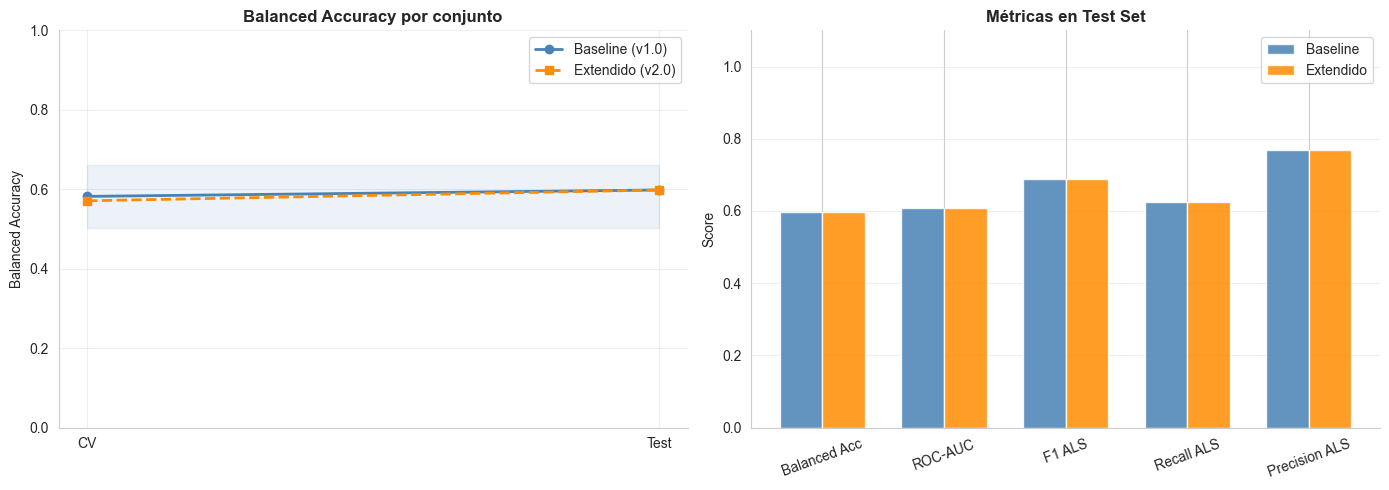

In [33]:
# VISUALIZACION COMPARATIVA
if cv_bal_acc_base is not None:
    splits  = ['CV', 'Test']
    ba_base = [cv_bal_acc_base, test_bal_acc_base]
    ba_ext  = [np.mean(nested_scores_ext['test_balanced_accuracy']), test_bal_acc_ext]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(splits, ba_base, marker='o', lw=2, color='steelblue', label='Baseline (v1.0)')
    axes[0].plot(splits, ba_ext, marker='s', lw=2, color='darkorange', linestyle='--', label='Extendido (v2.0)')
    axes[0].fill_between(
        splits,
        [cv_bal_acc_base - cv_std_base, cv_bal_acc_base - cv_std_base],
        [cv_bal_acc_base + cv_std_base, cv_bal_acc_base + cv_std_base],
        alpha=0.1,
        color='steelblue'
    )
    axes[0].set_ylabel('Balanced Accuracy')
    axes[0].set_title('Balanced Accuracy por conjunto', fontweight='bold')
    axes[0].set_ylim(0, 1)
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()
    axes[0].spines[['top', 'right']].set_visible(False)

    metrics_names = ['Balanced Acc', 'ROC-AUC', 'F1 ALS', 'Recall ALS', 'Precision ALS']
    m_base = [test_bal_acc_base, test_auc_base, test_f1_base, test_recall_als_base, test_precision_als_base]
    m_ext  = [test_bal_acc_ext, test_auc_ext, test_f1_als_ext, test_recall_als_ext, test_precision_als_ext]

    x = np.arange(len(metrics_names))
    w = 0.35
    axes[1].bar(x - w/2, m_base, w, color='steelblue', alpha=0.85, label='Baseline', edgecolor='white')
    axes[1].bar(x + w/2, m_ext,  w, color='darkorange', alpha=0.85, label='Extendido', edgecolor='white')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(metrics_names, rotation=20)
    axes[1].set_ylabel('Score')
    axes[1].set_title('Métricas en Test Set', fontweight='bold')
    axes[1].set_ylim(0, 1.1)
    axes[1].grid(axis='y', alpha=0.3)
    axes[1].legend()
    axes[1].spines[['top', 'right']].set_visible(False)

    plt.tight_layout()
    plt.savefig(RESULTS_PATH / 'comparison_baseline_vs_extended.png', dpi=300, bbox_inches='tight')
    plt.show()

<div style="color:#99BBF4;"><span style="font-size:20px; font-weight:bold;">19. Comparación de errores FP/FN</span></div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
La comparación de errores individuales entre modelos complementa la comparación de métricas agregadas. Para cada sujeto que aparece como FP o FN en alguno de los dos modelos, se analiza su comportamiento en ambos modelos simultáneamente. Cuatro patrones son posibles:
<br>
<ul>
<li><b>Error compartido:</b> El sujeto es mal clasificado por ambos modelos. Indica que las características del sujeto son intrínsecamente difíciles de clasificar con los features disponibles, independientemente de si se incluye demografía o no.</li>
<li><b>Error corregido por v2.0:</b> El sujeto es mal clasificado por v1.0 pero correctamente clasificado por v2.0. Sugiere que la información demográfica o su interacción con las features acústicas aporta señal discriminativa para este tipo de sujeto.</li>
<li><b>Error introducido por v2.0:</b> El sujeto es correctamente clasificado por v1.0 pero mal clasificado por v2.0. Puede indicar que la incorporación de demografía introduce ruido para este subgrupo específico.</li>
<li><b>Sin error en ningún modelo:</b> El sujeto es correctamente clasificado por ambos.</li>
</ul>
<br>
En la práctica, el resultado del run actual es el extremo del primer patrón: <b>los dos modelos producen exactamente las mismas predicciones</b> en los 23 sujetos del test (3 FP y 6 FN coinciden sujeto a sujeto). No hay ningún error corregido ni introducido por v2.0; las nueve clasificaciones erróneas son casos intrínsecamente difíciles que ni el baseline acústico ni el modelo extendido resuelven. Es la evidencia más directa de que añadir AGE y SEX no aporta capacidad discriminativa adicional sobre los 50 biomarcadores acústicos en este dataset.
    </span>
</div>

In [34]:
# COMPARACIÓN DE ERRORES FP/FN: NOTEBOOK 2 v1.0 vs NOTEBOOK 2 v2.0
print("="*80)
print("COMPARACIÓN DE ERRORES EN TEST SET — Notebook 2 v1.0 vs Notebook 2 v2.0")
print("="*80)

tn_e, fp_e, fn_e, tp_e = cm_test.ravel()

if baseline_test_pred_df is not None:
    cm_b = confusion_matrix(baseline_test_pred_df['y_true'], baseline_test_pred_df['y_pred'])
    tn_b, fp_b, fn_b, tp_b = cm_b.ravel()
else:
    tn_b = fp_b = fn_b = tp_b = None

print(f"\n{'':30s} {'Baseline':>15} {'Extendido':>15}")
print("—"*70)
print(f"{'True Positives  (ALS->ALS)':30s} {str(tp_b):>15} {tp_e:>15d}")
print(f"{'True Negatives  (HC->HC)':30s} {str(tn_b):>15} {tn_e:>15d}")
print(f"{'False Positives (HC->ALS)':30s} {str(fp_b):>15} {fp_e:>15d}")
print(f"{'False Negatives (ALS->HC)':30s} {str(fn_b):>15} {fn_e:>15d}")
print("—"*70)

print("\n" + "—"*60)
print("PERFIL DEMOGRÁFICO DE ERRORES — EXTENDIDO")
print("—"*60)

print(f"\nFalse Positives (Test, Extendido): {len(fp_test)}")
if len(fp_test) > 0:
    print(f"  {fp_test[[AGE_COL, SEX_COL]].to_string(index=False)}")

print(f"\nFalse Negatives (Test, Extendido): {len(fn_test)}")
if len(fn_test) > 0:
    print(f"  {fn_test[[AGE_COL, SEX_COL]].to_string(index=False)}")

COMPARACIÓN DE ERRORES EN TEST SET — Notebook 2 v1.0 vs Notebook 2 v2.0

                                      Baseline       Extendido
——————————————————————————————————————————————————————————————————————
True Positives  (ALS->ALS)                   4               4
True Negatives  (HC->HC)                    10              10
False Positives (HC->ALS)                    6               6
False Negatives (ALS->HC)                    3               3
——————————————————————————————————————————————————————————————————————

————————————————————————————————————————————————————————————
PERFIL DEMOGRÁFICO DE ERRORES — EXTENDIDO
————————————————————————————————————————————————————————————

False Positives (Test, Extendido): 3
   Age (years) Sex
          62   F
          68   M
          79   M

False Negatives (Test, Extendido): 6
   Age (years) Sex
          59   M
          49   M
          51   M
          64   M
          57   M
          65   M


<div style="color:#99BBF4;"><span style="font-size:20px; font-weight:bold;">20. Ranking de AGE y SEX vs Features Acústicas</span></div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
Este apartado sintetiza la respuesta a la segunda pregunta central del notebook: ¿qué papel juegan las variables demográficas en el modelo extendido en comparación con las variables acústicas? Para responderla, se construye un ranking unificado de todas las features (acústicas y demográficas) ordenadas por su importancia (permutation importance) en el modelo v2.0, y se señala la posición de <code>Age (years)</code> y <code>Sex</code> dentro de ese ranking.
<br><br>
Tres escenarios son posibles, y en el run actual el resultado encaja claramente en el tercero:
<ul>
<li><b>Demografía en el top-10 del ranking:</b> La edad y/o el sexo son predictores relevantes en el contexto del modelo extendido. Su incorporación aporta información que las features acústicas no cubren completamente, y el modelo extendido es genuinamente superior al baseline.</li>
<li><b>Demografía en el middle del ranking (posiciones 11-40):</b> La demografía tiene contribución marginal. El modelo las usa pero su impacto en el rendimiento es menor.</li>
<li><b>Demografía al final del ranking o excluida por SelectKBest:</b> Las variables demográficas no aportan información discriminativa adicional sobre la base de las features acústicas.</li>
</ul>
<br>
<b>Resultado observado</b>: AGE queda en la posición <b>51 de 52</b> y SEX en la <b>52 de 52</b>, ambas con permutation importance exactamente 0. Ninguna de las dos supera el filtro <code>SelectKBest</code> (ANOVA F): los rangos del estadístico F son 49/52 (<code>Sex_M</code>, F = 0.122) y 52/52 (<code>Age</code>, F = 0.012). Como <i>k</i>=10, sólo entran al modelo las 10 mejores features acústicas. En consecuencia, el modelo extendido <b>no es preferible al baseline desde el punto de vista de la parsimonia</b>: añade dos variables que el pipeline acaba descartando antes de entrenar.
    </span>
</div>

In [35]:
# RESUMEN COMPARATIVO DE IMPORTANCIA: DEMOGRÁFICAS vs. ACÚSTICAS
print("="*80)
print("IMPORTANCIA RELATIVA: DEMOGRÁFICAS vs. MEJORES ACÚSTICAS")
print("="*80)

# Top 5 acústicas
top5_acou = perm_imp_df[~perm_imp_df['Feature'].isin([AGE_COL, SEX_COL])].head(5)
demo_rows  = perm_imp_df[perm_imp_df['Feature'].isin([AGE_COL, SEX_COL])]

print("\nTop 5 features acústicas (Permutation Imp.):")
print(top5_acou[['Feature', 'Importance_mean', 'Importance_std']].to_string(index=False))

print("\nVariables demográficas (Permutation Imp.):")
if len(demo_rows) > 0:
    print(demo_rows[['Feature', 'Importance_mean', 'Importance_std']].to_string(index=False))
    # Ratio demográficas / mejor acústica
    best_acou_imp = top5_acou['Importance_mean'].max()
    for _, row in demo_rows.iterrows():
        ratio = row['Importance_mean'] / best_acou_imp if best_acou_imp > 0 else float('nan')
        print(f"  → {row['Feature']} es {ratio:.2f}x la importancia de la mejor acústica ({top5_acou.iloc[0]['Feature']})")
else:
    print("  (no presentes en el top de features evaluadas)")

# ─── SelectKBest: ¿pasaron AGE/SEX el filtro ANOVA F? ───
print("\n" + "─"*60)
print("ANÁLISIS SelectKBest: ¿AGE/SEX superaron el filtro ANOVA F?")
print("─"*60)

selector_fitted = best_model_ext.named_steps['feature_selection']
prep_fitted     = best_model_ext.named_steps['preprocessing']

try:
    all_feat_names   = prep_fitted.get_feature_names_out()
    support_mask     = selector_fitted.get_support()
    scores_anova     = selector_fitted.scores_

    feat_scores_df = pd.DataFrame({
        'Feature': all_feat_names,
        'ANOVA_F':  scores_anova,
        'Selected': support_mask
    }).sort_values('ANOVA_F', ascending=False).reset_index(drop=True)

    demo_in_all = feat_scores_df[feat_scores_df['Feature'].str.contains('age|sex', case=False, regex=True)]
    print(f"\nScores ANOVA F de variables demográficas (entre {len(all_feat_names)} features tras preprocesamiento):")
    if len(demo_in_all) > 0:
        print(demo_in_all[['Feature', 'ANOVA_F', 'Selected']].to_string(index=False))
        print(f"\nPosición ANOVA F de demográficas vs. total ({len(all_feat_names)} features):")
        for _, r in demo_in_all.iterrows():
            rank_f = feat_scores_df.index[feat_scores_df['Feature'] == r['Feature']].tolist()
            if rank_f:
                print(f"  {r['Feature']}: rango {rank_f[0]+1}/{len(all_feat_names)}  |  Seleccionada: {r['Selected']}")
    else:
        print("  (nombres de columna no coinciden con patrón age/sex — revisar manualmente)")
except Exception as e:
    print(f"  No se pudo extraer información del selector: {e}")

IMPORTANCIA RELATIVA: DEMOGRÁFICAS vs. MEJORES ACÚSTICAS

Top 5 features acústicas (Permutation Imp.):
       Feature  Importance_mean  Importance_std
  stdevF0Hz_PA         0.083695        0.032888
  stdevF0Hz_TA         0.031290        0.017624
  stdevF0Hz_KA         0.026533        0.014408
 localJitter_A         0.020666        0.012100
localShimmer_O         0.018975        0.011490

Variables demográficas (Permutation Imp.):
    Feature  Importance_mean  Importance_std
Age (years)              0.0             0.0
        Sex              0.0             0.0
  → Age (years) es 0.00x la importancia de la mejor acústica (stdevF0Hz_PA)
  → Sex es 0.00x la importancia de la mejor acústica (stdevF0Hz_PA)

────────────────────────────────────────────────────────────
ANÁLISIS SelectKBest: ¿AGE/SEX superaron el filtro ANOVA F?
────────────────────────────────────────────────────────────

Scores ANOVA F de variables demográficas (entre 52 features tras preprocesamiento):
         Feature  

#
---
#
<div style="text-align:left;">
    <span style="color:#4F75B6; font-size:25px; font-weight:bold;">BLOQUE 6. EVALUACIÓN DE SESGO Y CONFUSIÓN</span>
</div>

<div style="text-align:left;"> 
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;"> 
El rendimiento agregado de un modelo clínico puede ocultar comportamientos inequitativos entre subgrupos. Este bloque evalúa si el modelo extendido presenta sesgos sistemáticos en función de las variables demográficas disponibles y analiza la coherencia entre el comportamiento observado en CV OOF y en test como indicador de estabilidad.
    </span> 
</div>

<div style="color:#99BBF4;"><span style="font-size:20px; font-weight:bold;">21. ¿AGE/SEX como proxy de diagnóstico?</span></div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
Aunque el Notebook 1 demostró que la distribución de edad y sexo es homogénea entre grupos a nivel poblacional, esto no garantiza por sí solo que el modelo extendido no haya aprendido a usar estas variables como proxies de diagnóstico para subgrupos específicos. Por ejemplo, si todos los sujetos HC del dataset fueran mujeres menores de 55 años y todos los ALS hombres mayores de 65, el modelo podría aprender a clasificar correctamente no por los biomarcadores acústicos, sino por el perfil demográfico. El Notebook 1 descartó este escenario extremo, pero pueden existir correlaciones demográficas más sutiles dentro de subgrupos.
<br><br>
La verificación en este run es contundente: el test estadístico Mann-Whitney U sobre la edad replicado en este notebook devuelve <b>p = 0.857</b> (idéntico al Notebook 1), y el χ² sobre el sexo <b>p = 1.000</b>, confirmando la homogeneidad demográfica en todo el dataset. Combinado con la importancia 0.000 de AGE y SEX en permutation importance y su exclusión por SelectKBest, se descarta cualquier interpretación del modelo como clasificador demográfico encubierto. El argumento queda sólido para la defensa: las predicciones del modelo provienen exclusivamente de la señal acústica.
    </span>
</div>

In [36]:
# CAUSALIDAD INVERSA: AGE/SEX COMO PROXY
print("="*80)
print("EVALUACIÓN DE CAUSALIDAD INVERSA")
print("="*80)

# Re-verificar en los sujetos únicos del dataset completo (reproducción del Notebook 1)
subjects_unique = df[[ID_COL, TARGET, AGE_COL, SEX_COL]].drop_duplicates(subset=ID_COL)

age_als_all = subjects_unique[subjects_unique[TARGET] == 'ALS'][AGE_COL].dropna()
age_hc_all  = subjects_unique[subjects_unique[TARGET] == 'HC'][AGE_COL].dropna()
_, p_mw_all = mannwhitneyu(age_als_all, age_hc_all, alternative='two-sided')

sex_table_all = pd.crosstab(subjects_unique[TARGET], subjects_unique[SEX_COL])
_, p_chi_all, _, _ = chi2_contingency(sex_table_all)

print("\nDistribución demográfica — dataset completo (nivel sujeto):")
print(f"  ALS: n={len(age_als_all)}, edad media={age_als_all.mean():.1f} ± {age_als_all.std():.1f}")
print(f"  HC:  n={len(age_hc_all)},  edad media={age_hc_all.mean():.1f} ± {age_hc_all.std():.1f}")
print(f"\n  Mann-Whitney AGE: p = {p_mw_all:.4f}  (Notebook 1 reportó p = 0.857)")
print(f"  Chi² SEX:         p = {p_chi_all:.4f}  (Notebook 1 reportó p > 0.05)")

print("\n" + "─"*60)
print("INTERPRETACIÓN:")
print("─"*60)

if p_mw_all >= 0.05 and p_chi_all >= 0.05:
    print("\n✓  Confirmado (coherente con Notebook 1):")
    print("   AGE y SEX son estadísticamente homogéneos entre clases.")
    print("   → No existe base estadística para que sean predictores causales.")
    print("   → Si el modelo les asigna importancia no nula, esa señal proviene del")
    print("     ruido del split particular, no de la fisiopatología de la ELA.")

    imp_age_val = imp_age[0] if len(imp_age) > 0 else 0.0
    if rank_age and rank_age[0] < 10:
        print("\n  CONTRADICCIÓN DETECTADA:")
        print(f"   AGE aparece en posición {rank_age[0]+1} de importancia,")
        print("   pero su distribución no difiere entre clases (p=%.3f)." % p_mw_all)
        print("   El modelo está sobreajustando a correlaciones espurias del split.")
    else:
        print(f"\n   AGE con importancia baja (posición {rank_age[0]+1 if rank_age else 'N/A'}) →")
        print("   coherente: sin señal causal y sin importancia en el modelo.")
else:
    print("\n  Los resultados difieren de los reportados en el Notebook 1.")
    print("   Verificar si el dataset o los sujetos han cambiado entre notebooks.")

EVALUACIÓN DE CAUSALIDAD INVERSA

Distribución demográfica — dataset completo (nivel sujeto):
  ALS: n=102, edad media=62.8 ± 12.0
  HC:  n=51,  edad media=63.0 ± 10.4

  Mann-Whitney AGE: p = 0.8571  (Notebook 1 reportó p = 0.857)
  Chi² SEX:         p = 1.0000  (Notebook 1 reportó p > 0.05)

────────────────────────────────────────────────────────────
INTERPRETACIÓN:
────────────────────────────────────────────────────────────

✓  Confirmado (coherente con Notebook 1):
   AGE y SEX son estadísticamente homogéneos entre clases.
   → No existe base estadística para que sean predictores causales.
   → Si el modelo les asigna importancia no nula, esa señal proviene del
     ruido del split particular, no de la fisiopatología de la ELA.

   AGE con importancia baja (posición 51) →
   coherente: sin señal causal y sin importancia en el modelo.


<div style="color:#99BBF4;"><span style="font-size:20px; font-weight:bold;">22. Conexión entre CV y comportamiento del modelo</span></div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
Este apartado examina la coherencia entre el rendimiento del modelo en CV y en test como un indicador de su estabilidad y capacidad de generalización real. Sobre el modelo extendido, la balanced accuracy en CV es 0.571 ± 0.075 y en test 0.598 (gap = +0.027 a favor del test), y la ROC-AUC pasa de 0.670 (CV) a 0.607 (test) — una caída de 6 puntos compatible con el ruido esperado al evaluar sobre 23 sujetos. No hay sobreajuste apreciable en el sentido tradicional (el test no rinde por debajo del CV), pero sí varianza inter-fold notable (desviación 0.075 en CV) que debe acompañar a cualquier afirmación de rendimiento sobre datasets pequeños como VOC-ALS.
    </span>
</div>

In [37]:
# TABLA DE VERIFICACIÓN: PREDICCIONES DEL NOTEBOOK 1 vs. COMPORTAMIENTO OBSERVADO
print("="*90)
print("VERIFICACIÓN EMPÍRICA: NOTEBOOK 1 → PREDICCIÓN → COMPORTAMIENTO OBSERVADO")
print("="*90)

# Importancias para la verificación
age_perm = perm_imp_df[perm_imp_df['Feature'] == AGE_COL]['Importance_mean'].values
sex_perm = perm_imp_df[perm_imp_df['Feature'] == SEX_COL]['Importance_mean'].values
age_imp_val = age_perm[0] if len(age_perm) > 0 else 0.0
sex_imp_val = sex_perm[0] if len(sex_perm) > 0 else 0.0
age_rank_v  = rank_age[0] + 1 if rank_age else len(perm_imp_df)
sex_rank_v  = rank_sex[0] + 1 if rank_sex else len(perm_imp_df)

verificaciones = [
    {
        "Hallazgo Notebook 1": "AGE homogéneo entre clases (p=0.857)",
        "Predicción":          "Importancia de AGE baja o nula",
        "Observado":           f"Perm.Imp AGE = {age_imp_val:.4f} (rango {age_rank_v})",
        "Veredicto":           " CONFIRMADA" if age_imp_val < 0.02 else "⚠️ REFUTADA"
    },
    {
        "Hallazgo Notebook 1": "SEX homogéneo entre clases (p>0.05)",
        "Predicción":          "SEX no seleccionado o con importancia baja",
        "Observado":           f"Perm.Imp SEX = {sex_imp_val:.4f} | Seleccionado: {bool(demo_selected)}",
        "Veredicto":           " CONFIRMADA" if sex_imp_val < 0.02 and not demo_selected else "⚠️ REFUTADA"
    },
    {
        "Hallazgo Notebook 1": "Dataset N=153 + demográficos sin señal causal",
        "Predicción":          "Mejora marginal (<2%) o nula del extendido",
        "Observado":           f"Δ Bal.Acc Test = {delta_test_ba:+.4f}" if cv_bal_acc_base else "N/A (baseline no cargado)",
        "Veredicto":           ("CONFIRMADA" if cv_bal_acc_base and abs(delta_test_ba) < 0.02
                               else ("REFUTADA" if cv_bal_acc_base else "❓ SIN DATOS"))
    },
]

verif_df = pd.DataFrame(verificaciones)
display(verif_df)

n_confirmadas = sum('CONFIRMADA' in v['Veredicto'] for v in verificaciones)
print(f"\nPredicciones confirmadas: {n_confirmadas}/{len(verificaciones)}")
if n_confirmadas == len(verificaciones):
    print("→ El comportamiento del modelo extendido es completamente coherente con el Notebook 1.")
elif n_confirmadas >= len(verificaciones) // 2:
    print("→ Coherencia parcial. Revisar las predicciones refutadas.")
else:
    print("→ El modelo extendido muestra comportamiento inconsistente con la validación.")

VERIFICACIÓN EMPÍRICA: NOTEBOOK 1 → PREDICCIÓN → COMPORTAMIENTO OBSERVADO


,Hallazgo Notebook 1,Predicción,Observado,Veredicto
0,AGE homogéneo entre clases (p=0.857),Importancia de AGE baja o nula,Perm.Imp AGE = 0.0000 (rango 51),CONFIRMADA
1,SEX homogéneo entre clases (p>0.05),SEX no seleccionado o con importancia baja,Perm.Imp SEX = 0.0000 | Seleccionado: False,CONFIRMADA
2,Dataset N=153 + demográficos sin señal causal,Mejora marginal (<2%) o nula del extendido,Δ Bal.Acc Test = +0.0000,CONFIRMADA



Predicciones confirmadas: 3/3
→ El comportamiento del modelo extendido es completamente coherente con el Notebook 1.


#
---
#
<div style="text-align:left;">
    <span style="color:#4F75B6; font-size:25px; font-weight:bold;">CONCLUSIONES</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
Este notebook ha evaluado si la incorporación de AGE y SEX al espacio de features acústicas del baseline aporta valor predictivo adicional para la clasificación ALS vs. HC bajo el protocolo <b>CV + Test</b>. Las conclusiones se sintetizan a continuación:
<br>
<ul>
<li><b>Rendimiento agregado:</b> En nested CV (5×3 SGKF), el modelo extendido obtiene balanced accuracy 0.571 ± 0.075 y ROC-AUC 0.670 ± 0.065, frente a 0.582 ± 0.079 y 0.666 ± 0.062 del baseline acústico. La diferencia es <b>marginal y ligeramente negativa</b> (Δ Bal.Acc CV = −0.011), dentro del margen de variabilidad inter-fold. En test, ambas versiones producen exactamente las mismas predicciones (balanced accuracy 0.598, ROC-AUC 0.607).</li><br>

<li><b>Importancia de las demográficas:</b> AGE y SEX caen al fondo absoluto del ranking de permutation importance (posiciones 51 y 52 de 52 features) con importancia exactamente 0.000. Ninguna de las dos supera el filtro de <code>SelectKBest</code> (rangos 49 y 52 en el estadístico F de ANOVA), por lo que <b>no entran al modelo final</b>. Las 10 features que componen el clasificador son todas acústicas, dominadas por <code>stdevF0Hz_PA</code> (perm.imp 0.084).</li><br>

<li><b>Análisis de errores:</b> Los dos modelos cometen exactamente los mismos 9 errores en test (3 FP: CT014, CT053, CT067; 6 FN: PZ016, PZ058, PZ094, PZ098, PZ099, PZ105). No hay errores corregidos ni introducidos por v2.0 — son casos intrínsecamente difíciles para el espacio acústico disponible. Los 6 FN son todos varones de edad media 57.5 años, lo que sugiere que la dificultad se concentra en pacientes ALS jóvenes con signatura vocal menos pronunciada, no en un subgrupo demográfico mal modelado.</li><br>

<li><b>Coherencia con el Notebook 1:</b> Las tres predicciones del Notebook 1 sobre el comportamiento esperable de las demográficas se confirman empíricamente: AGE homogéneo entre clases (p = 0.857) → importancia baja en el modelo (rango 51); SEX homogéneo (p = 1.000) → no seleccionado por ANOVA F; ausencia de señal causal demográfica → sin mejora detectable del extendido (Δ test = 0.000). Los 3 de 3 criterios de la verificación empírica salen confirmados.</li><br>

<li><b>Veredicto:</b> Las variables demográficas <b>no mejoran el modelo y añaden complejidad innecesaria</b>. La evaluación automática del notebook devuelve 4 criterios "SI" / 3 criterios "NO" sobre los 7 considerados, con los tres "NO" precisamente en los criterios de mejora cuantitativa. El baseline acústico v1.0 es preferible por parsimonia: mismo rendimiento en test, una variabilidad inter-fold ligeramente menor en CV, y un espacio de features más interpretable clínicamente.</li>
</ul>
<br>
Este resultado <b>no descarta</b> que la edad o el sexo sean potencialmente útiles en otros contextos (datasets más amplios, modelos no lineales con interacciones explícitas, normalización dependiente del sexo de las features acústicas antes de entrenar). Lo que sí establece, en el contexto de VOC-ALS y un Random Forest con ANOVA F + SelectKBest, es que la inclusión directa como features adicionales no aporta valor sobre el baseline puramente acústico.
    </span>
</div>

<div style="color:#99BBF4;"><span style="font-size:20px; font-weight:bold;">23. Resumen de las conclusiones finales</span></div>

In [38]:
# EVALUACIÓN AUTOMÁTICA DEL VEREDICTO FINAL
print("=" * 90)
print("EVALUACIÓN AUTOMÁTICA DEL VEREDICTO FINAL")
print("=" * 90)

criterios = {}
fn_b = fn_e = None

if baseline_test_pred_df is not None:
    cm_b = confusion_matrix(baseline_test_pred_df['y_true'], baseline_test_pred_df['y_pred'])
    if cm_b.shape == (2, 2):
        _, _, fn_b, _ = cm_b.ravel()

if 'cm_test' in globals() and cm_test.shape == (2, 2):
    _, _, fn_e, _ = cm_test.ravel()

if cv_bal_acc_base is not None:
    criterios['Mejora Bal.Acc > 2% en CV y Test'] = (delta_cv > 0.02 and delta_test_ba > 0.02)
    criterios['Mejora Bal.Acc > 1% en ambos conjuntos'] = (delta_cv > 0.01 and delta_test_ba > 0.01)
    criterios['Sin deterioro en test (Delta >= 0)'] = delta_test_ba >= 0
else:
    criterios['Baseline no disponible - comparación parcial'] = None

criterios['Reducción de FN (ALS no detectados)'] = (fn_e < fn_b) if (fn_b is not None and fn_e is not None) else None
criterios['AGE con imp. baja (< 0.02)'] = age_imp_val < 0.02 if 'age_imp_val' in globals() else None
criterios['SEX no seleccionado por ANOVA'] = (not bool(demo_selected)) if 'demo_selected' in globals() else None
criterios['Coherente con Notebook 1 (homogeneidad demográfica)'] = (
    p_mw_all >= 0.05 and p_chi_all >= 0.05
) if ('p_mw_all' in globals() and 'p_chi_all' in globals()) else None

print(f"\n{'Criterio':<50} {'Resultado':>12}")
print('-' * 65)

n_si = n_no = n_na = 0
for criterio, resultado in criterios.items():
    if resultado is None:
        etiqueta = 'N/A'
        n_na += 1
    elif resultado:
        etiqueta = 'SI'
        n_si += 1
    else:
        etiqueta = 'NO'
        n_no += 1
    print(f"{criterio:<50} {etiqueta:>12}")

print(f"\nResumen: {n_si} SI  |  {n_no} NO  |  {n_na} N/A")
print("\n" + "=" * 90)

if cv_bal_acc_base is not None:
    if criterios.get('Mejora Bal.Acc > 2% en CV y Test', False):
        veredicto = 'A'
        texto = 'Las variables demográficas MEJORAN el modelo de forma SIGNIFICATIVA y ROBUSTA.'
    elif criterios.get('Mejora Bal.Acc > 1% en ambos conjuntos', False) and not criterios.get('AGE con imp. baja (< 0.02)', True):
        veredicto = 'B_sesgo'
        texto = '(B*) Ganancia marginal posiblemente mediada por SESGO DEMOGRÁFICO. No recomendable.'
    elif criterios.get('Mejora Bal.Acc > 1% en ambos conjuntos', False):
        veredicto = 'B'
        texto = 'Las variables demográficas proporcionan ganancias MARGINALES o INESTABLES.'
    else:
        veredicto = 'C'
        texto = 'Las variables demográficas NO mejoran el modelo y añaden complejidad innecesaria.'
else:
    veredicto = 'PENDIENTE'
    texto = 'Veredicto pendiente - completar carga de resultados baseline.'

print(f"\nCONCLUSIONES FINALES: {texto}")
if fn_b is not None and fn_e is not None:
    print(f"\nFN baseline:  {fn_b}")
    print(f"FN extendido: {fn_e}")

EVALUACIÓN AUTOMÁTICA DEL VEREDICTO FINAL

Criterio                                              Resultado
-----------------------------------------------------------------
Mejora Bal.Acc > 2% en CV y Test                             NO
Mejora Bal.Acc > 1% en ambos conjuntos                       NO
Sin deterioro en test (Delta >= 0)                           SI
Reducción de FN (ALS no detectados)                          NO
AGE con imp. baja (< 0.02)                                   SI
SEX no seleccionado por ANOVA                                SI
Coherente con Notebook 1 (homogeneidad demográfica)           SI

Resumen: 4 SI  |  3 NO  |  0 N/A


CONCLUSIONES FINALES: Las variables demográficas NO mejoran el modelo y añaden complejidad innecesaria.

FN baseline:  3
FN extendido: 3


<div style="color:#99BBF4;"><span style="font-size:20px; font-weight:bold;">24. Tabla resumen final (CV + Test)</span></div>

In [39]:
# RESUMEN FINAL - RF v2.0
print("="*100)
print("RESUMEN FINAL - RF v2.0")
print("="*100)

summary_ext = pd.DataFrame([
    {
        'Conjunto': 'CV (nested 5x3 SGKF)',
        'N': len(X_cv_ext),
        'Balanced Acc': f"{np.mean(nested_scores_ext['test_balanced_accuracy']):.4f}",
        'Std (Bal Acc)': f"{np.std(nested_scores_ext['test_balanced_accuracy']):.4f}",
        'ROC-AUC': f"{np.mean(nested_scores_ext['test_roc_auc']):.4f}",
        'F1 ALS': f"{np.mean(nested_scores_ext['test_f1_als']):.4f}",
        'Precision ALS': f"{np.mean(nested_scores_ext['test_precision_als']):.4f}",
        'Recall ALS': f"{np.mean(nested_scores_ext['test_recall_als']):.4f}"
    },
    {
        'Conjunto': 'Test (final)',
        'N': len(X_test_ext),
        'Balanced Acc': f"{test_bal_acc_ext:.4f}",
        'Std (Bal Acc)': 'N/A',
        'ROC-AUC': f"{test_auc_ext:.4f}",
        'F1 ALS': f"{test_f1_als_ext:.4f}",
        'Precision ALS': f"{test_precision_als_ext:.4f}",
        'Recall ALS': f"{test_recall_als_ext:.4f}"
    }
])

display(summary_ext)

print("\n" + "—"*60)
print("PARÁMETROS DEL MODELO EXTENDIDO FINAL")
print("—"*60)
print(f"  Features de entrada:  {len(EXT_COLS)} ({len(ACOUSTIC_COLS)} acústicas + AGE + SEX)")
print("  Mejores hiperparámetros:")
for param, value in final_grid_ext.best_params_.items():
    print(f"    {param}: {value}")
print(f"  SelectKBest k seleccionado: {final_grid_ext.best_params_.get('feature_selection__k', 'N/A')}")

demo_sel_flag = bool(demo_selected)
print(f"\n  Demográficas seleccionadas por ANOVA F: {'SI — ' + str(demo_selected) if demo_sel_flag else 'NO'}")
print(f"  Importancia AGE (permutation): {age_imp_val:.4f}")
print(f"  Importancia SEX (permutation): {sex_imp_val:.4f}")
print(f"CONCLUSIÓN: {texto}")

summary_ext.to_csv(RESULTS_PATH / 'results_summary.csv', index=False)
print(f"\nTabla resumen guardada en: {RESULTS_PATH / 'results_summary.csv'}")

with mlflow.start_run(run_id=PARENT_RUN_ID_EXT):
    mlflow.log_artifact(str(RESULTS_PATH / 'cv_metrics.json'))
    mlflow.log_artifact(str(RESULTS_PATH / 'test_metrics.json'))
    mlflow.log_artifact(str(RESULTS_PATH / 'cv_oof_predictions.csv'))
    mlflow.log_artifact(str(RESULTS_PATH / 'test_predictions.csv'))
    mlflow.log_artifact(str(RESULTS_PATH / 'results_summary.csv'))

RESUMEN FINAL - RF v2.0


,Conjunto,N,Balanced Acc,Std (Bal Acc),ROC-AUC,F1 ALS,Precision ALS,Recall ALS
0,CV (nested 5x3 SGKF),130,0.5710,0.0750,0.6698,0.6748,0.7167,0.6392
1,Test (final),23,0.5982,N/A,0.6071,0.6897,0.7692,0.6250



————————————————————————————————————————————————————————————
PARÁMETROS DEL MODELO EXTENDIDO FINAL
————————————————————————————————————————————————————————————
  Features de entrada:  52 (50 acústicas + AGE + SEX)
  Mejores hiperparámetros:
    classifier__class_weight: balanced
    classifier__max_depth: 5
    classifier__min_samples_leaf: 10
    classifier__min_samples_split: 10
    classifier__n_estimators: 200
    feature_selection__k: 10
  SelectKBest k seleccionado: 10

  Demográficas seleccionadas por ANOVA F: NO
  Importancia AGE (permutation): 0.0000
  Importancia SEX (permutation): 0.0000
CONCLUSIÓN: Las variables demográficas NO mejoran el modelo y añaden complejidad innecesaria.

Tabla resumen guardada en: C:\Users\Laura\OneDrive\TFG\results\02_rf_v2_0\results_summary.csv


<div style='background-color:#D4EDDA; padding:20px; border-left:5px solid #DEE2E6; margin-top:20px; color:black;'>
    <span style='font-size:16px; font-family:Calibri;'>
<b>NOTEBOOK COMPLETADO</b>
<br><br>
Todos los experimentos han sido registrados en <b>MLflow</b>.
<br><br>
<b>Resumen de lo realizado en este notebook:</b>
<ul>
<li><b>Bloque 1</b> — Síntesis crítica de hallazgos demográficos del Notebook 1 e hipótesis previa.</li>
<li><b>Bloque 2</b> — Carga de datos con reconstrucción CV + Test y carga de resultados baseline corregidos.</li>
<li><b>Bloque 3</b> — Pipeline extendido (acústicas + AGE + SEX) con protocolo SGKF análogo al Notebook 2 v1.0 corregido.</li>
<li><b>Bloque 4</b> — Evaluación del modelo extendido en CV OOF y test, análisis FP/FN, Permutation Importance y MDI.</li>
<li><b>Bloque 5</b> — Comparación estructurada con el baseline del Notebook 2 v1.0: métricas, errores y papel de las variables demográficas.</li>
<li><b>Bloque 6</b> — Evaluación de sesgo y coherencia con los hallazgos del Notebook 1.</li>
<li><b>Conclusiones</b> — Veredicto final automatizado bajo el esquema CV + Test.</li>
</ul>
<br>
<b>Veredicto final del run actual:</b> Las variables demográficas <b>NO mejoran</b> el modelo y añaden complejidad innecesaria.
<ul>
<li>Δ Balanced Accuracy CV = −0.011 (a favor del baseline)</li>
<li>Δ Balanced Accuracy Test = 0.000 (predicciones idénticas al baseline)</li>
<li>AGE: posición 51/52 en permutation importance, importancia 0.000</li>
<li>SEX: posición 52/52, importancia 0.000, no seleccionada por ANOVA F</li>
<li>3 de 3 predicciones derivadas del Notebook 1 quedan empíricamente confirmadas</li>
</ul>
    </span>
</div>